# Improving Customer Experience Through Supply Chain Analytics
## DataCo Supply Chain EDA

This project analyzes the DataCo Supply Chain dataset to identify factors affecting customer experience, delivery performance, product profitability, and operational efficiency.

The goal is to determine where delivery issues are happening, which customers and products are most affected, what the financial impact is, and what actions the business can take to improve performance.

## 1. Import Pertienent Libraries, Upload CSV, Perform Data Inspection

In [2]:
import matplotlib.pyplot as plt
import numpy
import pandas as pd
from google.colab import files
import io

In [3]:
data = files.upload()

Saving DataCo_SupplyChain_Dataset_RAW.csv to DataCo_SupplyChain_Dataset_RAW.csv


In [6]:
filename = list(data.keys())[0]

df = pd.read_csv(
    io.StringIO(data[filename].decode('latin1'))
)

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/18 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/18 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/18 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/18 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/18 11:24,Standard Class


In [7]:
df.shape


(180519, 53)

In [8]:
df.columns


Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [10]:
df.isnull().sum().sort_values(ascending=False).head(25)

,0
Product Description,180519
Order Zipcode,155679
Customer Lname,8
Customer Zipcode,3
Days for shipment (scheduled),0
Sales per customer,0
Benefit per order,0
Delivery Status,0
Late_delivery_risk,0
Customer City,0


## 2. Perform Data Cleanup
### The columns Product Description and Order Zipcode have missing values for nearly the entire dataset so I'm going to drop them.

In [11]:
df_clean = df.copy()

# Drop columns that are mostly missing or not useful for this analysis
columns_to_drop = [
    'Product Description',
    'Order Zipcode',
    'Customer Fname',
    'Customer Lname',
    'Customer Email',
    'Customer Password',
    'Customer Street'
]

df_clean = df_clean.drop(columns=columns_to_drop, errors='ignore')


In [12]:
df_clean.shape

(180519, 46)

In [13]:
# Checking Those Missing Values Again
df_clean.isnull().sum().sort_values(ascending=False).head(20)

,0
Customer Zipcode,3
Type,0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Days for shipping (real),0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


In [14]:
# Next up I'll make the column names more uniform
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('(', '', regex=False)
    .str.replace(')', '', regex=False)
    .str.replace('-', '_')
)

df_clean.columns

Index(['type', 'days_for_shipping_real', 'days_for_shipment_scheduled',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_id', 'customer_segment', 'customer_state',
       'customer_zipcode', 'department_id', 'department_name', 'latitude',
       'longitude', 'market', 'order_city', 'order_country',
       'order_customer_id', 'order_date_dateorders', 'order_id',
       'order_item_cardprod_id', 'order_item_discount',
       'order_item_discount_rate', 'order_item_id', 'order_item_product_price',
       'order_item_profit_ratio', 'order_item_quantity', 'sales',
       'order_item_total', 'order_profit_per_order', 'order_region',
       'order_state', 'order_status', 'product_card_id', 'product_category_id',
       'product_image', 'product_name', 'product_price', 'product_status',
       'shipping_date_dateorders', 'shipping_mode'],
      dtype='object')

In [15]:
df_clean.columns.tolist()

['type',
 'days_for_shipping_real',
 'days_for_shipment_scheduled',
 'benefit_per_order',
 'sales_per_customer',
 'delivery_status',
 'late_delivery_risk',
 'category_id',
 'category_name',
 'customer_city',
 'customer_country',
 'customer_id',
 'customer_segment',
 'customer_state',
 'customer_zipcode',
 'department_id',
 'department_name',
 'latitude',
 'longitude',
 'market',
 'order_city',
 'order_country',
 'order_customer_id',
 'order_date_dateorders',
 'order_id',
 'order_item_cardprod_id',
 'order_item_discount',
 'order_item_discount_rate',
 'order_item_id',
 'order_item_product_price',
 'order_item_profit_ratio',
 'order_item_quantity',
 'sales',
 'order_item_total',
 'order_profit_per_order',
 'order_region',
 'order_state',
 'order_status',
 'product_card_id',
 'product_category_id',
 'product_image',
 'product_name',
 'product_price',
 'product_status',
 'shipping_date_dateorders',
 'shipping_mode']

## 3. Create Business KPI Fields
### In this section, I create new fields that support customer experience, product, BI, and operations analysis. These fields include delivery delay, late delivery flags, profit margin, date fields, and customer experience risk categories.

### 3.1 Convert Date Columns

In [17]:
## Converting date columns so I can analyze trends over time, such as: Monthly Sales, Monthly Late Delivery Rate, Shipping performance over time
# and Seasonal Product Demand

df_clean['order_date_dateorders'] = pd.to_datetime(
    df_clean['order_date_dateorders'],
    errors='coerce'
)

df_clean['shipping_date_dateorders'] = pd.to_datetime(
    df_clean['shipping_date_dateorders'],
    errors='coerce'
)

/tmp/ipykernel_1118/2232882642.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['order_date_dateorders'] = pd.to_datetime(
/tmp/ipykernel_1118/2232882642.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['shipping_date_dateorders'] = pd.to_datetime(


In [18]:
# Double Checking the Data Conversion
df_clean[['order_date_dateorders', 'shipping_date_dateorders']].head(10)


,order_date_dateorders,shipping_date_dateorders
0,2018-01-31 22:56:00,2018-02-03 22:56:00
1,2018-01-13 12:27:00,2018-01-18 12:27:00
2,2018-01-13 12:06:00,2018-01-17 12:06:00
3,2018-01-13 11:45:00,2018-01-16 11:45:00
4,2018-01-13 11:24:00,2018-01-15 11:24:00
5,2018-01-13 11:03:00,2018-01-19 11:03:00
6,2018-01-13 10:42:00,2018-01-15 10:42:00
7,2018-01-13 10:21:00,2018-01-15 10:21:00
8,2018-01-13 10:00:00,2018-01-16 10:00:00
9,2018-01-13 09:39:00,2018-01-15 09:39:00


### 3.2 Create Date Fields for Trend Analysis

In [19]:
# These fields will help with dashboard filters and trend charts

df_clean['order_year'] = df_clean['order_date_dateorders'].dt.year
df_clean['order_month'] = df_clean['order_date_dateorders'].dt.month
df_clean['order_month_name'] = df_clean['order_date_dateorders'].dt.month_name()
df_clean['order_day_of_week'] = df_clean['order_date_dateorders'].dt.day_name()
df_clean['order_year_month'] = df_clean['order_date_dateorders'].dt.to_period('M').astype(str)

### 3.3 Create Delivery Performance Fields

In [20]:
# Create delivery performance fields

df_clean['shipping_delay_days'] = (
    df_clean['days_for_shipping_real'] - df_clean['days_for_shipment_scheduled']
)

df_clean['is_late_delivery'] = df_clean['late_delivery_risk'].apply(
    lambda x: 1 if x == 1 else 0
)

df_clean['delivery_status_clean'] = df_clean['is_late_delivery'].apply(
    lambda x: 'Late' if x == 1 else 'On Time'
)

In [21]:
df_clean[
    [
        'days_for_shipping_real',
        'days_for_shipment_scheduled',
        'shipping_delay_days',
        'late_delivery_risk',
        'is_late_delivery',
        'delivery_status',
        'delivery_status_clean'
    ]
].head(10)

,days_for_shipping_real,days_for_shipment_scheduled,shipping_delay_days,late_delivery_risk,is_late_delivery,delivery_status,delivery_status_clean
0,3,4,-1,0,0,Advance shipping,On Time
1,5,4,1,1,1,Late delivery,Late
2,4,4,0,0,0,Shipping on time,On Time
3,3,4,-1,0,0,Advance shipping,On Time
4,2,4,-2,0,0,Advance shipping,On Time
5,6,4,2,0,0,Shipping canceled,On Time
6,2,1,1,1,1,Late delivery,Late
7,2,1,1,1,1,Late delivery,Late
8,3,2,1,1,1,Late delivery,Late
9,2,1,1,1,1,Late delivery,Late


### 3.4 Create Profitability Fields


In [22]:
import numpy as np

df_clean['profit_margin'] = np.where(
    df_clean['sales'] != 0,
    df_clean['order_profit_per_order'] / df_clean['sales'],
    0
)

df_clean['profit_margin_pct'] = df_clean['profit_margin'] * 100

In [23]:
df_clean[
    [
        'sales',
        'order_profit_per_order',
        'profit_margin',
        'profit_margin_pct'
    ]
].head(10)

,sales,order_profit_per_order,profit_margin,profit_margin_pct
0,327.75,91.250000,0.278413,27.841342
1,327.75,-249.089996,-0.760000,-75.999999
2,327.75,-247.779999,-0.756003,-75.600305
3,327.75,22.860001,0.069748,6.974829
4,327.75,134.210007,0.409489,40.948896
5,327.75,18.580000,0.056690,5.668955
6,327.75,95.180000,0.290404,29.040427
7,327.75,68.430000,0.208787,20.878719
8,327.75,133.720001,0.407994,40.799390
9,327.75,132.149994,0.403204,40.320364


### 3.5 Create Customer Experience Risk Categories

#### A Quick Note on Delivery Metrics

The `is_late_delivery` field identifies whether an order was officially flagged as late in the original dataset. The `cx_delivery_risk` field groups orders by the size of the shipping delay compared with the scheduled shipping timeline.

These two fields are related, but they are not identical. `is_late_delivery` is used for official late-delivery rate calculations, while `cx_delivery_risk` is used to describe the severity of delivery delays from a customer experience perspective.

In [24]:
df_clean['cx_delivery_risk'] = df_clean['shipping_delay_days'].apply(
    lambda x: 'High Risk' if x > 2
    else 'Moderate Risk' if x > 0
    else 'Low Risk'
)

In [25]:
df_clean[
    [
        'days_for_shipping_real',
        'days_for_shipment_scheduled',
        'shipping_delay_days',
        'delivery_status_clean',
        'cx_delivery_risk'
    ]
].head(10)

,days_for_shipping_real,days_for_shipment_scheduled,shipping_delay_days,delivery_status_clean,cx_delivery_risk
0,3,4,-1,On Time,Low Risk
1,5,4,1,Late,Moderate Risk
2,4,4,0,On Time,Low Risk
3,3,4,-1,On Time,Low Risk
4,2,4,-2,On Time,Low Risk
5,6,4,2,On Time,Moderate Risk
6,2,1,1,Late,Moderate Risk
7,2,1,1,Late,Moderate Risk
8,3,2,1,Late,Moderate Risk
9,2,1,1,Late,Moderate Risk


In [26]:
df_clean['cx_delivery_risk'].value_counts()

,count
cx_delivery_risk,
Moderate Risk,89365
Low Risk,77119
High Risk,14035


### 3.6 Final KPI Field Check

In [27]:
df_clean[
    [
        'order_date_dateorders',
        'shipping_date_dateorders',
        'order_year',
        'order_month',
        'order_month_name',
        'order_day_of_week',
        'order_year_month',
        'days_for_shipping_real',
        'days_for_shipment_scheduled',
        'shipping_delay_days',
        'late_delivery_risk',
        'is_late_delivery',
        'delivery_status_clean',
        'cx_delivery_risk',
        'sales',
        'order_profit_per_order',
        'profit_margin_pct'
    ]
].head(10)

,order_date_dateorders,shipping_date_dateorders,order_year,order_month,order_month_name,order_day_of_week,order_year_month,days_for_shipping_real,days_for_shipment_scheduled,shipping_delay_days,late_delivery_risk,is_late_delivery,delivery_status_clean,cx_delivery_risk,sales,order_profit_per_order,profit_margin_pct
0,2018-01-31 22:56:00,2018-02-03 22:56:00,2018,1,January,Wednesday,2018-01,3,4,-1,0,0,On Time,Low Risk,327.75,91.250000,27.841342
1,2018-01-13 12:27:00,2018-01-18 12:27:00,2018,1,January,Saturday,2018-01,5,4,1,1,1,Late,Moderate Risk,327.75,-249.089996,-75.999999
2,2018-01-13 12:06:00,2018-01-17 12:06:00,2018,1,January,Saturday,2018-01,4,4,0,0,0,On Time,Low Risk,327.75,-247.779999,-75.600305
3,2018-01-13 11:45:00,2018-01-16 11:45:00,2018,1,January,Saturday,2018-01,3,4,-1,0,0,On Time,Low Risk,327.75,22.860001,6.974829
4,2018-01-13 11:24:00,2018-01-15 11:24:00,2018,1,January,Saturday,2018-01,2,4,-2,0,0,On Time,Low Risk,327.75,134.210007,40.948896
5,2018-01-13 11:03:00,2018-01-19 11:03:00,2018,1,January,Saturday,2018-01,6,4,2,0,0,On Time,Moderate Risk,327.75,18.580000,5.668955
6,2018-01-13 10:42:00,2018-01-15 10:42:00,2018,1,January,Saturday,2018-01,2,1,1,1,1,Late,Moderate Risk,327.75,95.180000,29.040427
7,2018-01-13 10:21:00,2018-01-15 10:21:00,2018,1,January,Saturday,2018-01,2,1,1,1,1,Late,Moderate Risk,327.75,68.430000,20.878719
8,2018-01-13 10:00:00,2018-01-16 10:00:00,2018,1,January,Saturday,2018-01,3,2,1,1,1,Late,Moderate Risk,327.75,133.720001,40.799390
9,2018-01-13 09:39:00,2018-01-15 09:39:00,2018,1,January,Saturday,2018-01,2,1,1,1,1,Late,Moderate Risk,327.75,132.149994,40.320364


In [28]:
# Executive KPI Summary
total_orders = len(df_clean)
late_orders = df_clean['is_late_delivery'].sum()
on_time_orders = total_orders - late_orders

late_delivery_rate = late_orders / total_orders
on_time_delivery_rate = on_time_orders / total_orders

total_sales = df_clean['sales'].sum()
total_profit = df_clean['order_profit_per_order'].sum()

avg_shipping_days = df_clean['days_for_shipping_real'].mean()
avg_scheduled_shipping_days = df_clean['days_for_shipment_scheduled'].mean()
avg_shipping_delay = df_clean['shipping_delay_days'].mean()

print(f"Total Orders: {total_orders:,}")
print(f"Late Orders: {late_orders:,}")
print(f"On-Time Orders: {on_time_orders:,}")
print(f"Late Delivery Rate: {late_delivery_rate:.2%}")
print(f"On-Time Delivery Rate: {on_time_delivery_rate:.2%}")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Actual Shipping Days: {avg_shipping_days:.2f}")
print(f"Average Scheduled Shipping Days: {avg_scheduled_shipping_days:.2f}")
print(f"Average Shipping Delay: {avg_shipping_delay:.2f}")

Total Orders: 180,519
Late Orders: 98,977
On-Time Orders: 81,542
Late Delivery Rate: 54.83%
On-Time Delivery Rate: 45.17%
Total Sales: $36,784,735.01
Total Profit: $3,966,902.97
Average Actual Shipping Days: 3.50
Average Scheduled Shipping Days: 2.93
Average Shipping Delay: 0.57


### Executive KPI Summary

The cleaned dataset contains 180,519 total orders, with 98,977 orders flagged as late. This results in a late delivery rate of 54.83%, meaning more than half of all orders experienced a late delivery flag.

The dataset includes approximately 36.8 million USD in total sales and 4.0 million USD in total profit. Average actual shipping time was 3.50 days compared with an average scheduled shipping time of 2.93 days, creating an average shipping delay of 0.57 days.

These results suggest that delivery performance is a major customer experience and operations issue worth investigating further by shipping mode, customer segment, region, and product category.

## Part 4: Customer Experience and Delivery Performance Analysis
### In this section, I analyze delivery performance across shipping modes, customer segments, markets, regions, and product categories. The goal is to identify where late deliveries are most common and which areas may be creating customer experience or operational risk.

### 4.1 Late Delivery Rate by Shipping Mode

This analysis compares shipping modes by total orders, late orders, average shipping time, average delay, sales, profit, and late delivery rate. This helps identify which shipping methods may be contributing most to customer experience issues.

In [30]:
shipping_mode_summary = (
    df_clean
    .groupby('shipping_mode')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('is_late_delivery', 'sum'),
        avg_actual_shipping_days=('days_for_shipping_real', 'mean'),
        avg_scheduled_shipping_days=('days_for_shipment_scheduled', 'mean'),
        avg_shipping_delay=('shipping_delay_days', 'mean'),
        total_sales=('sales', 'sum'),
        total_profit=('order_profit_per_order', 'sum')
    )
    .reset_index()
)

shipping_mode_summary['late_delivery_rate'] = (
    shipping_mode_summary['late_orders'] / shipping_mode_summary['total_orders']
)

shipping_mode_summary['late_delivery_rate_pct'] = (
    shipping_mode_summary['late_delivery_rate'] * 100
).round(2)

shipping_mode_summary = shipping_mode_summary.sort_values(
    by='late_delivery_rate_pct',
    ascending=False
)

shipping_mode_summary

,shipping_mode,total_orders,late_orders,avg_actual_shipping_days,avg_scheduled_shipping_days,avg_shipping_delay,total_sales,total_profit,late_delivery_rate,late_delivery_rate_pct
0,First Class,27814,26513,2.000000,1.0,1.000000,5.674370e+06,6.431219e+05,0.953225,95.32
2,Second Class,35216,26987,3.990828,2.0,1.990828,7.145445e+06,7.503082e+05,0.766328,76.63
1,Same Day,9737,4454,0.478279,0.0,0.478279,1.942529e+06,2.030184e+05,0.457430,45.74
3,Standard Class,107752,41023,3.995907,4.0,-0.004093,2.202239e+07,2.370454e+06,0.380717,38.07


### 4.2 Making the Table Easier to Read

In [31]:

shipping_mode_summary_display = shipping_mode_summary.copy()

shipping_mode_summary_display['avg_actual_shipping_days'] = shipping_mode_summary_display['avg_actual_shipping_days'].round(2)
shipping_mode_summary_display['avg_scheduled_shipping_days'] = shipping_mode_summary_display['avg_scheduled_shipping_days'].round(2)
shipping_mode_summary_display['avg_shipping_delay'] = shipping_mode_summary_display['avg_shipping_delay'].round(2)
shipping_mode_summary_display['total_sales'] = shipping_mode_summary_display['total_sales'].round(2)
shipping_mode_summary_display['total_profit'] = shipping_mode_summary_display['total_profit'].round(2)

shipping_mode_summary_display

,shipping_mode,total_orders,late_orders,avg_actual_shipping_days,avg_scheduled_shipping_days,avg_shipping_delay,total_sales,total_profit,late_delivery_rate,late_delivery_rate_pct
0,First Class,27814,26513,2.00,1.0,1.00,5674369.76,643121.92,0.953225,95.32
2,Second Class,35216,26987,3.99,2.0,1.99,7145444.82,750308.17,0.766328,76.63
1,Same Day,9737,4454,0.48,0.0,0.48,1942528.56,203018.43,0.457430,45.74
3,Standard Class,107752,41023,4.00,4.0,-0.00,22022391.88,2370454.45,0.380717,38.07


#### Shipping Mode Insight

First Class and Second Class shipping had the highest late delivery rates, at 95.32% and 76.63% respectively. This suggests that faster shipping promises may be creating customer experience risk when actual fulfillment performance does not match the scheduled delivery timeline.

Standard Class handled the largest number of orders and generated the most sales, but had a much lower late delivery rate of 38.07%. It's average actual shipping time was nearly equal to its scheduled shipping time, suggesting that Standard Class may be more operationally reliable despite being a slower shipping option.

From a business perspective, DataCo should review whether First Class and Second Class delivery timelines are realistic, whether fulfillment capacity supports these faster shipping options, and whether customer expectations need to be adjusted.

### 4.3 Shipping Mode Late Delivery Comparison

The chart below visualizes late delivery rate by shipping mode. This helps highlight whether faster shipping options, such as First Class or Second Class, are meeting their promised delivery timelines or creating additional customer experience risk.

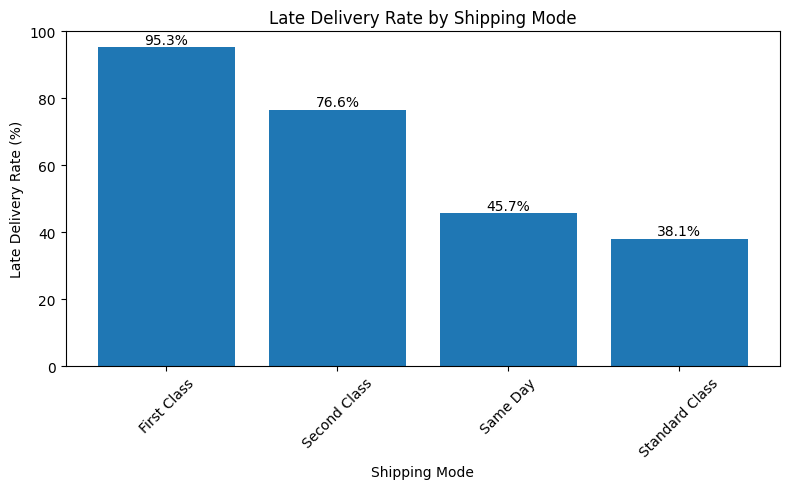

In [32]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    shipping_mode_summary['shipping_mode'],
    shipping_mode_summary['late_delivery_rate_pct']
)

plt.title('Late Delivery Rate by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Late Delivery Rate (%)')
plt.xticks(rotation=45)
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

#### Chart Interpretation

The chart shows that First Class and Second Class shipping have the highest late delivery rates. First Class has a late delivery rate above 95%, while Second Class is above 76%.

This suggests that faster shipping options may be creating customer experience risk because actual fulfillment performance is not consistently meeting the scheduled delivery timeline. Standard Class has the lowest late delivery rate, even though it handles the largest order volume.

### 4.4 Late Delivery Rate by Customer Segment

This analysis compares delivery performance across customer segments. The goal is to identify whether certain customer groups experience late deliveries at higher rates, which may indicate customer experience risk for specific segments.

In [33]:
customer_segment_summary = (
    df_clean
    .groupby('customer_segment')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('is_late_delivery', 'sum'),
        avg_actual_shipping_days=('days_for_shipping_real', 'mean'),
        avg_scheduled_shipping_days=('days_for_shipment_scheduled', 'mean'),
        avg_shipping_delay=('shipping_delay_days', 'mean'),
        total_sales=('sales', 'sum'),
        total_profit=('order_profit_per_order', 'sum')
    )
    .reset_index()
)

customer_segment_summary['late_delivery_rate'] = (
    customer_segment_summary['late_orders'] / customer_segment_summary['total_orders']
)

customer_segment_summary['late_delivery_rate_pct'] = (
    customer_segment_summary['late_delivery_rate'] * 100
).round(2)

customer_segment_summary = customer_segment_summary.sort_values(
    by='late_delivery_rate_pct',
    ascending=False
)

customer_segment_summary

,customer_segment,total_orders,late_orders,avg_actual_shipping_days,avg_scheduled_shipping_days,avg_shipping_delay,total_sales,total_profit,late_delivery_rate,late_delivery_rate_pct
2,Home Office,32226,17747,3.511450,2.933501,0.577949,6.520538e+06,6.908403e+05,0.550704,55.07
0,Consumer,93504,51248,3.497508,2.932591,0.564917,1.909579e+07,2.073488e+06,0.548084,54.81
1,Corporate,54789,29982,3.489788,2.929603,0.560185,1.116841e+07,1.202575e+06,0.547227,54.72


In [34]:
# This creates a cleaner display table

customer_segment_summary_display = customer_segment_summary.copy()

customer_segment_summary_display['avg_actual_shipping_days'] = customer_segment_summary_display['avg_actual_shipping_days'].round(2)
customer_segment_summary_display['avg_scheduled_shipping_days'] = customer_segment_summary_display['avg_scheduled_shipping_days'].round(2)
customer_segment_summary_display['avg_shipping_delay'] = customer_segment_summary_display['avg_shipping_delay'].round(2)
customer_segment_summary_display['total_sales'] = customer_segment_summary_display['total_sales'].round(2)
customer_segment_summary_display['total_profit'] = customer_segment_summary_display['total_profit'].round(2)

customer_segment_summary_display

,customer_segment,total_orders,late_orders,avg_actual_shipping_days,avg_scheduled_shipping_days,avg_shipping_delay,total_sales,total_profit,late_delivery_rate,late_delivery_rate_pct
2,Home Office,32226,17747,3.51,2.93,0.58,6520538.02,690840.34,0.550704,55.07
0,Consumer,93504,51248,3.50,2.93,0.56,19095790.16,2073487.67,0.548084,54.81
1,Corporate,54789,29982,3.49,2.93,0.56,11168406.84,1202574.96,0.547227,54.72


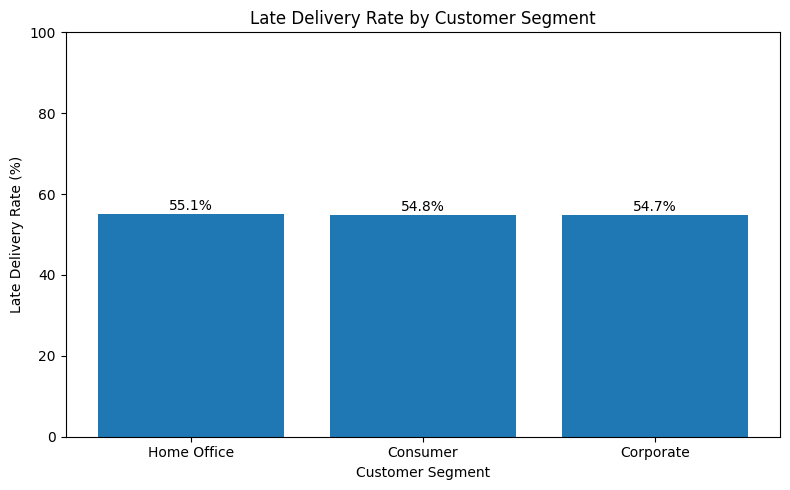

In [35]:
### Customer Segment Late Delivery Chart

## The chart below compares late delivery rates across customer segments.
# This visualization helps show whether delivery issues are  concentrated among specific customer groups or distributed evenly across segments.

plt.figure(figsize=(8, 5))

bars = plt.bar(
    customer_segment_summary['customer_segment'],
    customer_segment_summary['late_delivery_rate_pct']
)

plt.title('Late Delivery Rate by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Late Delivery Rate (%)')
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

#### Chart Interpretation

Late delivery rates are very similar across all customer segments. Home Office customers had the highest late delivery rate at 55.1%, followed by Consumer customers at 54.8% and Corporate customers at 54.7%.

Because the difference between segments is small, the results suggest that late delivery is not concentrated in one specific customer group. Instead, delivery performance appears to be a broader operational issue affecting all customer segments at nearly the same rate.

From a customer experience perspective, this means improvement efforts should focus less on segment-specific solutions and more on system-wide fulfillment, shipping, and delivery process improvements.

## 4.5 Late Delivery Rate by Market

This analysis compares delivery performance across markets. The goal is to identify whether late deliveries are concentrated in specific geographic markets, which may reveal regional fulfillment or logistics challenges.


In [36]:
# This creates a market summary table sorted by major markets

market_summary = (
    df_clean
    .groupby('market')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('is_late_delivery', 'sum'),
        avg_actual_shipping_days=('days_for_shipping_real', 'mean'),
        avg_scheduled_shipping_days=('days_for_shipment_scheduled', 'mean'),
        avg_shipping_delay=('shipping_delay_days', 'mean'),
        total_sales=('sales', 'sum'),
        total_profit=('order_profit_per_order', 'sum')
    )
    .reset_index()
)

market_summary['late_delivery_rate'] = (
    market_summary['late_orders'] / market_summary['total_orders']
)

market_summary['late_delivery_rate_pct'] = (
    market_summary['late_delivery_rate'] * 100
).round(2)

market_summary = market_summary.sort_values(
    by='late_delivery_rate_pct',
    ascending=False
)

market_summary

market_summary_display = market_summary.copy()

market_summary_display['avg_actual_shipping_days'] = market_summary_display['avg_actual_shipping_days'].round(2)
market_summary_display['avg_scheduled_shipping_days'] = market_summary_display['avg_scheduled_shipping_days'].round(2)
market_summary_display['avg_shipping_delay'] = market_summary_display['avg_shipping_delay'].round(2)
market_summary_display['total_sales'] = market_summary_display['total_sales'].round(2)
market_summary_display['total_profit'] = market_summary_display['total_profit'].round(2)

market_summary_display

,market,total_orders,late_orders,avg_actual_shipping_days,avg_scheduled_shipping_days,avg_shipping_delay,total_sales,total_profit,late_delivery_rate,late_delivery_rate_pct
1,Europe,50252,27743,3.49,2.92,0.57,10872396.80,1169442.96,0.552078,55.21
3,Pacific Asia,41260,22712,3.50,2.93,0.57,8273743.74,857753.44,0.550460,55.05
4,USCA,25799,14138,3.48,2.92,0.57,5066528.71,564313.78,0.548006,54.80
0,Africa,11614,6340,3.51,2.95,0.56,2294452.93,252071.18,0.545893,54.59
2,LATAM,51594,28044,3.51,2.95,0.56,10277612.84,1123321.61,0.543552,54.36


### Market Late Delivery Chart

The chart below compares late delivery rates across markets. This visualization helps identify whether delivery issues are more severe in certain geographic markets.

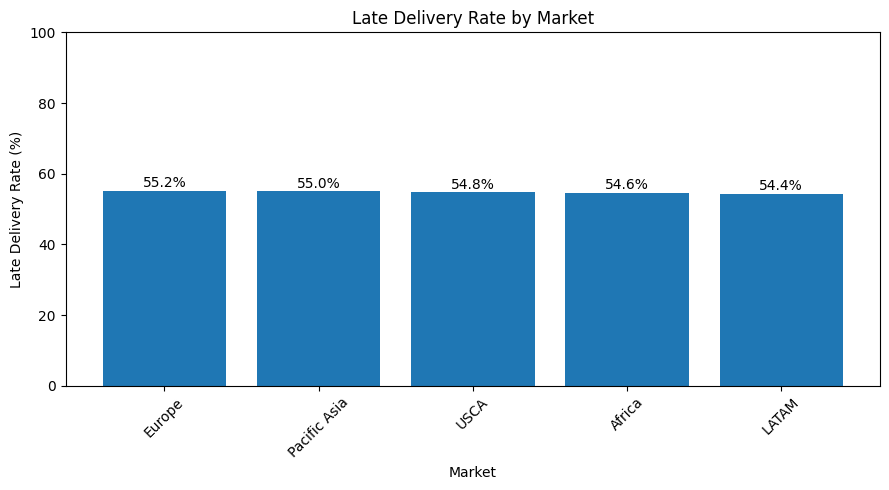

In [37]:
# Creates bar chart showing late delivery rate by market

plt.figure(figsize=(9, 5))

bars = plt.bar(
    market_summary['market'],
    market_summary['late_delivery_rate_pct']
)

plt.title('Late Delivery Rate by Market')
plt.xlabel('Market')
plt.ylabel('Late Delivery Rate (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

#### Chart Interpretation

Late delivery rates are very similar across all markets. Europe had the highest late delivery rate at 55.2%, followed by Pacific Asia at 55.0% and USCA at 54.8%. However, the difference between the highest and lowest markets is less than one percentage point.

This suggests that late delivery is not concentrated in a single geographic market. Instead, delivery performance appears to be a system-wide operations issue affecting markets at nearly the same rate.

From an operations and BI perspective, market-level analysis alone may be too broad to identify the root cause of late deliveries. A deeper regional analysis may provide more useful insight by showing whether specific order regions have higher delivery risk.

## 4.6 Late Delivery Rate by Order Region

Market-level late delivery rates were very similar, so this analysis drills down into order regions. The goal is to determine whether more specific regions show higher delivery risk that may not be visible at the broader market level.

In [38]:
# Creating a region summary table showing all orders, shipping days, delays, total sales and total profit

region_summary = (
    df_clean
    .groupby('order_region')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('is_late_delivery', 'sum'),
        avg_actual_shipping_days=('days_for_shipping_real', 'mean'),
        avg_scheduled_shipping_days=('days_for_shipment_scheduled', 'mean'),
        avg_shipping_delay=('shipping_delay_days', 'mean'),
        total_sales=('sales', 'sum'),
        total_profit=('order_profit_per_order', 'sum')
    )
    .reset_index()
)

region_summary['late_delivery_rate'] = (
    region_summary['late_orders'] / region_summary['total_orders']
)

region_summary['late_delivery_rate_pct'] = (
    region_summary['late_delivery_rate'] * 100
).round(2)

region_summary = region_summary.sort_values(
    by='late_delivery_rate_pct',
    ascending=False
)

region_summary

region_summary_display = region_summary.copy()

region_summary_display['avg_actual_shipping_days'] = region_summary_display['avg_actual_shipping_days'].round(2)
region_summary_display['avg_scheduled_shipping_days'] = region_summary_display['avg_scheduled_shipping_days'].round(2)
region_summary_display['avg_shipping_delay'] = region_summary_display['avg_shipping_delay'].round(2)
region_summary_display['total_sales'] = region_summary_display['total_sales'].round(2)
region_summary_display['total_profit'] = region_summary_display['total_profit'].round(2)

region_summary_display

,order_region,total_orders,late_orders,avg_actual_shipping_days,avg_scheduled_shipping_days,avg_shipping_delay,total_sales,total_profit,late_delivery_rate,late_delivery_rate_pct
2,Central Africa,1677,972,3.56,2.92,0.64,327263.02,33447.27,0.579606,57.96
13,South Asia,7731,4350,3.50,2.90,0.60,1553680.92,165703.90,0.562670,56.27
5,East Africa,1852,1036,3.51,2.94,0.57,376234.90,43167.73,0.559395,55.94
22,Western Europe,27109,15140,3.50,2.90,0.60,5894380.77,625446.08,0.558486,55.85
14,South of USA,4045,2256,3.49,2.91,0.58,785783.95,88114.88,0.557726,55.77
8,Eastern Europe,3920,2182,3.50,2.92,0.58,774266.57,79717.05,0.556633,55.66
6,East of USA,6915,3849,3.50,2.92,0.58,1371111.99,156263.30,0.556616,55.66
15,Southeast Asia,9539,5297,3.50,2.94,0.56,1932495.57,211342.82,0.555299,55.53
4,Central Asia,553,306,3.42,2.77,0.65,109839.93,13045.28,0.553345,55.33
20,West Asia,6009,3322,3.49,2.92,0.57,1174671.78,118815.41,0.552837,55.28


### Order Region Late Delivery Chart

The chart below compares late delivery rates across order regions. This helps identify whether specific regions have higher delivery risk than the overall market-level analysis suggested.

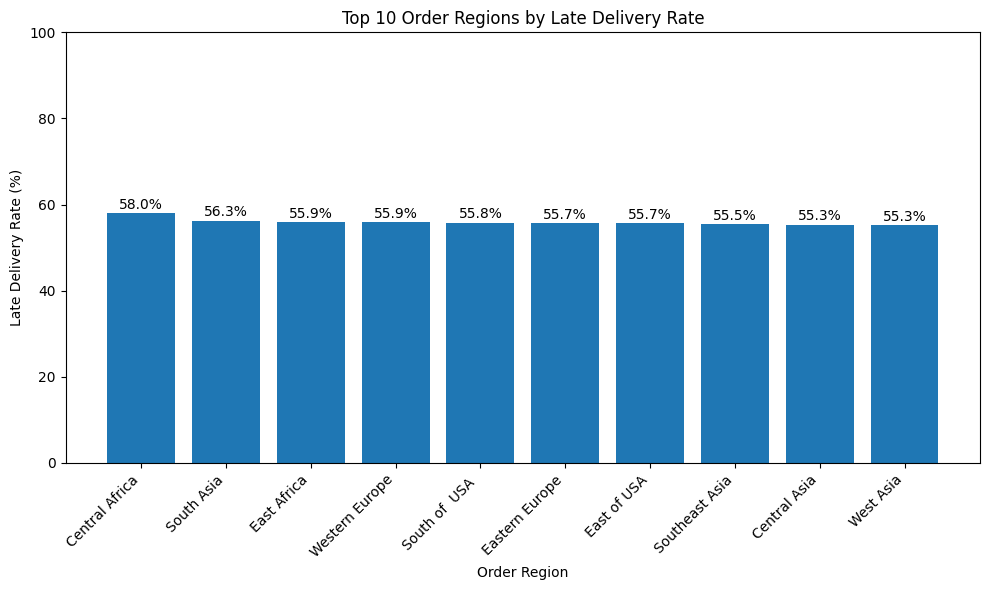

In [39]:
# Create bar chart showing the top 10 regions by late delivery rate

top_10_region_late_delivery = region_summary.head(10)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    top_10_region_late_delivery['order_region'],
    top_10_region_late_delivery['late_delivery_rate_pct']
)

plt.title('Top 10 Order Regions by Late Delivery Rate')
plt.xlabel('Order Region')
plt.ylabel('Late Delivery Rate (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

#### Chart Interpretation

The top 10 order regions by late delivery rate are relatively close together, ranging from 55.3% to 58.0%. Central Africa had the highest late delivery rate at 58.0%, followed by South Asia at 56.3% and East Africa at 55.9%.

Although some regions perform slightly worse than others, there is no single region with an extreme late delivery rate compared with the overall dataset average of 54.83%. This suggests that regional geography may contribute to delivery variation, but it does not appear to be the primary driver of late deliveries.

Combined with the market-level analysis, these results suggest that DataCo’s late delivery issue is more likely connected to operational factors such as shipping mode, fulfillment timelines, or service-level expectations rather than one specific geographic region.

### Geographic Analysis Summary

Both market-level and region-level analysis show that late delivery rates are fairly consistent across geographic areas. While some regions have slightly higher late delivery rates, there is no major geographic outlier.

This suggests that geography alone is unlikely to explain DataCo’s late delivery problem. The strongest signal so far remains shipping mode, especially First Class and Second Class shipping.

## 4.7 Late Delivery Rate by Product Category

This analysis compares delivery performance across product categories. The goal is to determine whether certain categories are more likely to experience late deliveries, which may indicate product-specific fulfillment or inventory challenges.

In [40]:
category_summary = (
    df_clean
    .groupby('category_name')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('is_late_delivery', 'sum'),
        avg_actual_shipping_days=('days_for_shipping_real', 'mean'),
        avg_scheduled_shipping_days=('days_for_shipment_scheduled', 'mean'),
        avg_shipping_delay=('shipping_delay_days', 'mean'),
        total_sales=('sales', 'sum'),
        total_profit=('order_profit_per_order', 'sum'),
        avg_profit_margin_pct=('profit_margin_pct', 'mean')
    )
    .reset_index()
)

category_summary['late_delivery_rate'] = (
    category_summary['late_orders'] / category_summary['total_orders']
)

category_summary['late_delivery_rate_pct'] = (
    category_summary['late_delivery_rate'] * 100
).round(2)

category_summary = category_summary.sort_values(
    by='late_delivery_rate_pct',
    ascending=False
)

category_summary

category_summary_display = category_summary.copy()

category_summary_display['avg_actual_shipping_days'] = category_summary_display['avg_actual_shipping_days'].round(2)
category_summary_display['avg_scheduled_shipping_days'] = category_summary_display['avg_scheduled_shipping_days'].round(2)
category_summary_display['avg_shipping_delay'] = category_summary_display['avg_shipping_delay'].round(2)
category_summary_display['total_sales'] = category_summary_display['total_sales'].round(2)
category_summary_display['total_profit'] = category_summary_display['total_profit'].round(2)
category_summary_display['avg_profit_margin_pct'] = category_summary_display['avg_profit_margin_pct'].round(2)

category_summary_display

,category_name,total_orders,late_orders,avg_actual_shipping_days,avg_scheduled_shipping_days,avg_shipping_delay,total_sales,total_profit,avg_profit_margin_pct,late_delivery_rate,late_delivery_rate_pct
23,Golf Bags & Carts,61,42,3.34,2.57,0.77,10369.39,1810.07,17.46,0.688525,68.85
32,Lacrosse,343,206,3.62,2.96,0.66,39464.79,4364.29,11.62,0.600583,60.06
37,Pet Supplies,492,290,3.39,2.68,0.71,41524.80,3589.26,8.64,0.589431,58.94
8,Cameras,592,344,3.34,2.69,0.65,267607.69,30289.80,11.32,0.581081,58.11
41,Strength Training,111,64,3.75,3.08,0.67,54895.53,332.31,5.13,0.576577,57.66
1,As Seen on TV!,68,39,3.63,2.97,0.66,20597.94,714.43,5.50,0.573529,57.35
36,Music,434,248,3.48,2.91,0.57,113122.10,14436.32,12.76,0.571429,57.14
0,Accessories,1780,1014,3.50,2.91,0.59,133671.51,16643.52,11.96,0.569663,56.97
19,Fitness Accessories,309,176,3.57,2.96,0.61,35601.44,5258.39,13.56,0.569579,56.96
5,Books,405,229,3.39,2.86,0.53,12587.40,883.01,7.02,0.565432,56.54


### Product Category Late Delivery Chart

The chart below shows the top 10 product categories by late delivery rate. This helps identify whether certain product categories are more likely to create fulfillment or customer experience risk.

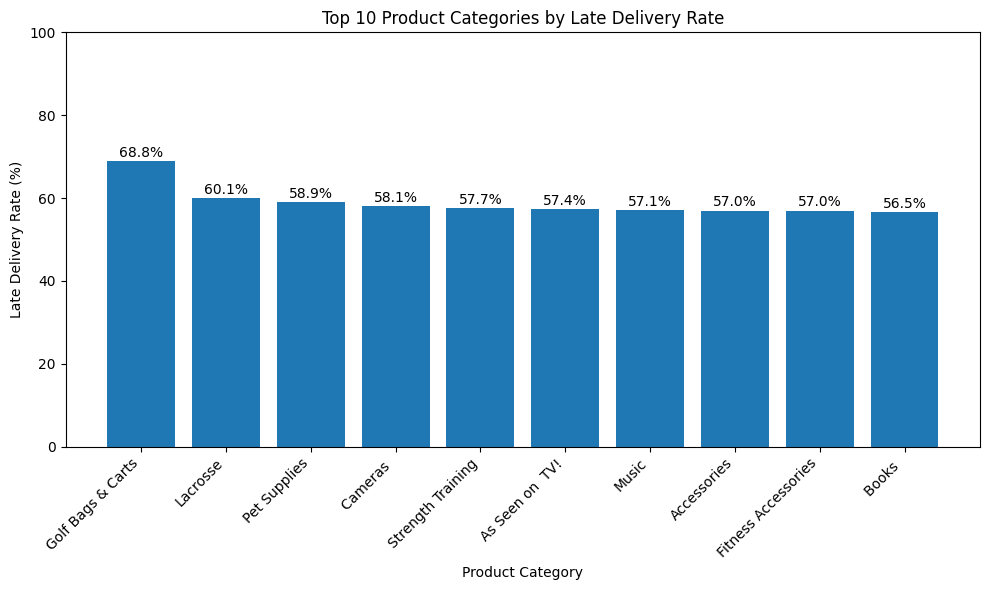

In [41]:
# Create bar chart showing the top 10 product categories by late delivery rate

top_10_category_late_delivery = category_summary.head(10)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    top_10_category_late_delivery['category_name'],
    top_10_category_late_delivery['late_delivery_rate_pct']
)

plt.title('Top 10 Product Categories by Late Delivery Rate')
plt.xlabel('Product Category')
plt.ylabel('Late Delivery Rate (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

#### Chart Interpretation

The product category analysis shows more variation than the customer segment and market-level analyses. Golf Bags & Carts had the highest late delivery rate at 68.8%, which is noticeably higher than the overall dataset late delivery rate of 54.83%.

Several other categories, including Lacrosse, Pet Supplies, Cameras, and Strength Training, also had late delivery rates above the overall average. This suggests that some product categories may create greater fulfillment or delivery risk than others.

From a product and operations perspective, DataCo should investigate whether high-risk categories have inventory availability issues, supplier delays, warehouse handling challenges, or shipping constraints that make them more difficult to fulfill on time.

## 4.8 High Sales and High Late Delivery Risk by Product Category

This analysis combines product category sales performance with late delivery risk. The goal is to identify categories that are financially important but may also create customer experience risk due to high late delivery rates.

In [42]:
category_risk_summary = (
    df_clean
    .groupby('category_name')
    .agg(
        total_orders=('order_id', 'count'),
        late_orders=('is_late_delivery', 'sum'),
        total_sales=('sales', 'sum'),
        total_profit=('order_profit_per_order', 'sum'),
        avg_profit_margin_pct=('profit_margin_pct', 'mean'),
        avg_shipping_delay=('shipping_delay_days', 'mean')
    )
    .reset_index()
)

category_risk_summary['late_delivery_rate_pct'] = (
    category_risk_summary['late_orders'] / category_risk_summary['total_orders'] * 100
).round(2)

category_risk_summary = category_risk_summary.sort_values(
    by='total_sales',
    ascending=False
)

category_risk_summary.head(10)

category_risk_display = category_risk_summary.copy()

category_risk_display['total_sales'] = category_risk_display['total_sales'].round(2)
category_risk_display['total_profit'] = category_risk_display['total_profit'].round(2)
category_risk_display['avg_profit_margin_pct'] = category_risk_display['avg_profit_margin_pct'].round(2)
category_risk_display['avg_shipping_delay'] = category_risk_display['avg_shipping_delay'].round(2)

category_risk_display.head(10)

,category_name,total_orders,late_orders,total_sales,total_profit,avg_profit_margin_pct,avg_shipping_delay,late_delivery_rate_pct
18,Fishing,17325,9516,6929653.69,756220.77,10.91,0.56,54.93
12,Cleats,24551,13496,4431942.78,494636.92,11.19,0.58,54.97
9,Camping & Hiking,13729,7487,4118425.57,427455.57,10.38,0.55,54.53
10,Cardio Equipment,12487,6805,3694843.20,383011.10,10.62,0.55,54.50
47,Women's Apparel,21035,11476,3147800.00,350421.03,11.00,0.56,54.56
46,Water Sports,15540,8517,3113844.68,325146.96,10.45,0.57,54.81
34,Men's Footwear,22246,12121,2891757.66,311902.82,10.79,0.56,54.49
30,Indoor/Outdoor Games,19298,10565,2888993.91,318451.43,11.13,0.56,54.75
38,Shop By Sport,10984,6058,1309522.04,129813.96,10.09,0.58,55.15
13,Computers,442,224,663000.00,69656.81,10.51,0.45,50.68


#### 4.8.1 Create a high-sales/high-risk flag

Now we’ll identify categories that are above average in both sales and late delivery rate.

In [47]:
avg_category_sales = category_risk_summary['total_sales'].mean()
avg_late_delivery_rate = category_risk_summary['late_delivery_rate_pct'].mean()

category_risk_summary['sales_risk_category'] = category_risk_summary.apply(
    lambda row: 'High Sales / High Delivery Risk'
    if row['total_sales'] >= avg_category_sales and row['late_delivery_rate_pct'] >= avg_late_delivery_rate
    else 'Other',
    axis=1
)

category_risk_summary[
    category_risk_summary['sales_risk_category'] == 'High Sales / High Delivery Risk'
].sort_values(by='total_sales', ascending=False)

,category_name,total_orders,late_orders,total_sales,total_profit,avg_profit_margin_pct,avg_shipping_delay,late_delivery_rate_pct,sales_risk_category


###$ High-Sales Product Categories and Late Delivery Risk

The chart below shows the top 10 product categories by total sales, with each category’s late delivery rate displayed above the bar. This helps identify categories that are financially important and may also create customer experience risk.

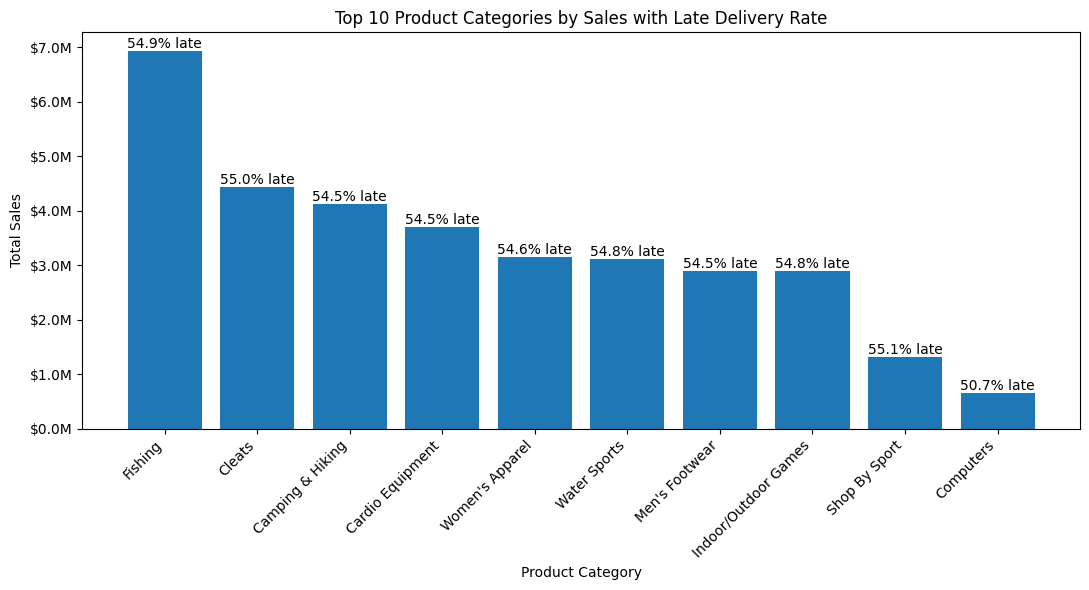

In [49]:
# Create chart showing top 10 product categories by sales with late delivery rate labels
import matplotlib.ticker as mtick

plt.figure(figsize=(11, 6))

top_10_sales_categories = category_risk_summary.head(10)

bars = plt.bar(
    top_10_sales_categories['category_name'],
    top_10_sales_categories['total_sales']
)

plt.title('Top 10 Product Categories by Sales with Late Delivery Rate')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)

for bar, late_rate in zip(bars, top_10_sales_categories['late_delivery_rate_pct']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{late_rate:.1f}% late',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Chart Interpretation

The top-selling product categories generally have late delivery rates near the overall dataset average of 54.83%. Fishing generated the highest total sales, with a late delivery rate of 54.9%, while Cleats, Camping & Hiking, Cardio Equipment, Women's Apparel, Water Sports, Men's Footwear, and Indoor/Outdoor Games all had late delivery rates close to the overall average.

This suggests that DataCo's highest-revenue categories are not necessarily experiencing unusually high late delivery rates compared with the overall business. However, because these categories generate the most sales, even average late delivery rates may still represent significant customer experience and revenue risk.

Computers had the lowest late delivery rate among the top 10 sales categories at 50.7%, suggesting it may be performing slightly better from a fulfillment perspective.

From a business perspective, DataCo should prioritize monitoring high-sales categories such as Fishing, Cleats, and Camping & Hiking because delivery issues in these categories affect a larger share of revenue and customer orders.

### Part 4 Summary

The customer experience and delivery performance analysis shows that late delivery is a major issue across the dataset, with an overall late delivery rate of 54.83%.

The strongest signal was shipping mode. First Class and Second Class shipping had much higher late delivery rates than Same Day and Standard Class shipping, suggesting that faster shipping options may not be consistently meeting promised fulfillment timelines.

Customer segment, market, and order region showed much smaller differences, suggesting that late delivery is not isolated to one specific customer group or geographic area. Product category showed some variation, with Golf Bags & Carts standing out as a higher-risk category. However, the highest-sales categories generally had late delivery rates close to the overall average.

Overall, the findings suggest that DataCo should focus on reviewing shipping mode performance, fulfillment promises, and high-revenue product categories where even average late delivery rates can affect many customers.

## Part 5: Product and Profitability Analysis

In this section, I analyze sales, profit, and margin performance across product categories. The goal is to identify which categories are driving revenue, which are contributing the most profit, and which may need closer review due to weak margins or profitability concerns.

### 5.1 Total Sales by Product Category

This analysis identifies the product categories generating the highest total sales. Total sales helps show which categories are most important from a revenue perspective.

In [50]:
category_sales_summary = (
    df_clean
    .groupby('category_name')
    .agg(
        total_orders=('order_id', 'count'),
        total_sales=('sales', 'sum'),
        total_profit=('order_profit_per_order', 'sum'),
        avg_profit_margin_pct=('profit_margin_pct', 'mean'),
        avg_discount_rate=('order_item_discount_rate', 'mean'),
        late_delivery_rate_pct=('is_late_delivery', lambda x: x.mean() * 100)
    )
    .reset_index()
)

category_sales_summary['total_sales'] = category_sales_summary['total_sales'].round(2)
category_sales_summary['total_profit'] = category_sales_summary['total_profit'].round(2)
category_sales_summary['avg_profit_margin_pct'] = category_sales_summary['avg_profit_margin_pct'].round(2)
category_sales_summary['avg_discount_rate'] = (category_sales_summary['avg_discount_rate'] * 100).round(2)
category_sales_summary['late_delivery_rate_pct'] = category_sales_summary['late_delivery_rate_pct'].round(2)

category_sales_summary = category_sales_summary.sort_values(
    by='total_sales',
    ascending=False
)

category_sales_summary.head(10)

,category_name,total_orders,total_sales,total_profit,avg_profit_margin_pct,avg_discount_rate,late_delivery_rate_pct
18,Fishing,17325,6929653.69,756220.77,10.91,10.17,54.93
12,Cleats,24551,4431942.78,494636.92,11.19,10.16,54.97
9,Camping & Hiking,13729,4118425.57,427455.57,10.38,10.17,54.53
10,Cardio Equipment,12487,3694843.20,383011.10,10.62,10.17,54.50
47,Women's Apparel,21035,3147800.00,350421.03,11.00,10.17,54.56
46,Water Sports,15540,3113844.68,325146.96,10.45,10.17,54.81
34,Men's Footwear,22246,2891757.66,311902.82,10.79,10.17,54.49
30,Indoor/Outdoor Games,19298,2888993.91,318451.43,11.13,10.15,54.75
38,Shop By Sport,10984,1309522.04,129813.96,10.09,10.14,55.15
13,Computers,442,663000.00,69656.81,10.51,10.22,50.68


#### Sales Category Insight

Fishing generated the highest total sales among all product categories, with approximately \$6.93 million in revenue and \$756K in profit. Cleats had the highest order volume among the top-selling categories, with 24,551 orders, and generated approximately \$4.43 million in sales.

The top-selling categories generally have similar average profit margins, ranging from about 10% to 11%, and similar average discount rates near 10%. This suggests that revenue differences across these categories are driven more by order volume and sales activity than by major differences in pricing or discount strategy.

From a business perspective, Fishing, Cleats, and Camping & Hiking should be closely monitored because they represent major revenue drivers. Even small improvements in fulfillment, margin, or customer experience within these categories could have a meaningful financial impact.

### 5.2 Top 10 Product Categories by Total Sales

This visualization shows the top 10 product categories by total sales. The goal is to make the revenue concentration across categories easier to see and identify which product categories are the biggest drivers of overall business performance.

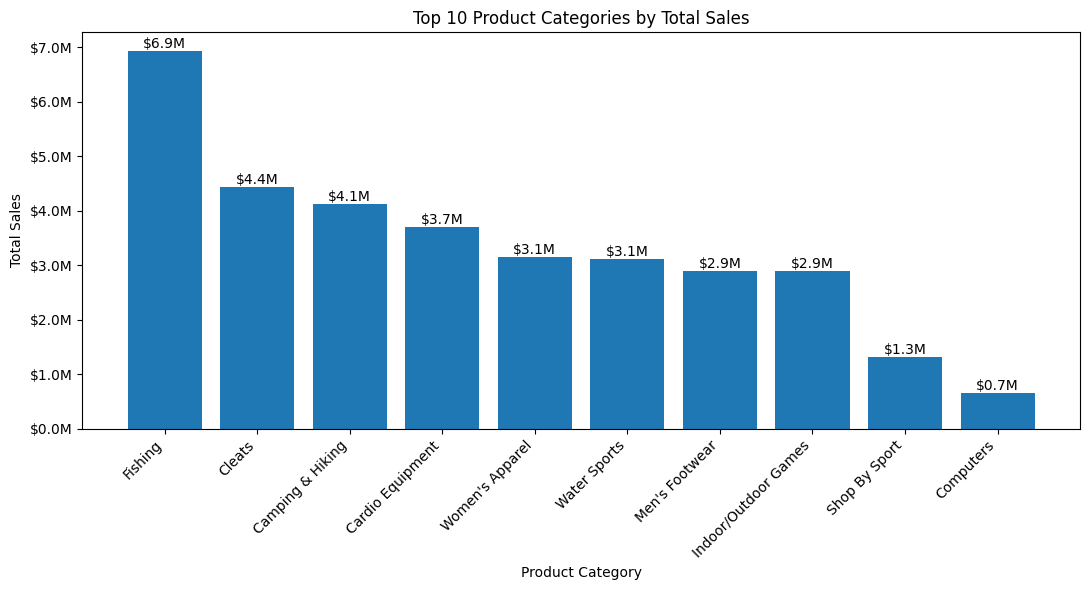

In [51]:
# Create bar chart showing the top 10 product categories by total sales

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

top_10_sales = category_sales_summary.head(10)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    top_10_sales['category_name'],
    top_10_sales['total_sales']
)

plt.title('Top 10 Product Categories by Total Sales')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')

# Format y-axis in millions of dollars
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'${height/1_000_000:.1f}M',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Sales by Product Category Chart

The chart above highlights the top 10 product categories by total sales. This helps show which categories contribute the most revenue and should receive close attention in future product, operations, and customer experience analysis.

Fishing is the highest-performing product category by total sales, generating approximately \$6.9 million in revenue. This is noticeably higher than the next highest category, Cleats, which generated approximately \$4.4 million.

The top three categories — Fishing, Cleats, and Camping & Hiking — account for a large share of revenue among the top-selling categories. This suggests that DataCo’s sales performance is concentrated in a relatively small group of product categories.

From a product and BI perspective, these categories should be prioritized in dashboard monitoring because changes in their sales, profitability, fulfillment performance, or customer experience could have a meaningful impact on overall business performance.

### 5.3 Total Profit by Product Category

This analysis identifies the product categories generating the highest total profit. Comparing profit to sales helps determine whether the categories with the most revenue are also the categories contributing the most financial value to the business.

In [53]:
# This reuses the summary table I  created in 5.1, but sorts it by total profit instead of total sales.
category_profit_summary = category_sales_summary.sort_values(
    by='total_profit',
    ascending=False
)

category_profit_summary.head(10)

,category_name,total_orders,total_sales,total_profit,avg_profit_margin_pct,avg_discount_rate,late_delivery_rate_pct
18,Fishing,17325,6929653.69,756220.77,10.91,10.17,54.93
12,Cleats,24551,4431942.78,494636.92,11.19,10.16,54.97
9,Camping & Hiking,13729,4118425.57,427455.57,10.38,10.17,54.53
10,Cardio Equipment,12487,3694843.20,383011.10,10.62,10.17,54.50
47,Women's Apparel,21035,3147800.00,350421.03,11.00,10.17,54.56
46,Water Sports,15540,3113844.68,325146.96,10.45,10.17,54.81
30,Indoor/Outdoor Games,19298,2888993.91,318451.43,11.13,10.15,54.75
34,Men's Footwear,22246,2891757.66,311902.82,10.79,10.17,54.49
38,Shop By Sport,10984,1309522.04,129813.96,10.09,10.14,55.15
13,Computers,442,663000.00,69656.81,10.51,10.22,50.68


#### Profit by Product Category Chart

The chart below shows the top 10 product categories by total profit. This helps identify which categories contribute the most profit and whether they match the top revenue-generating categories.

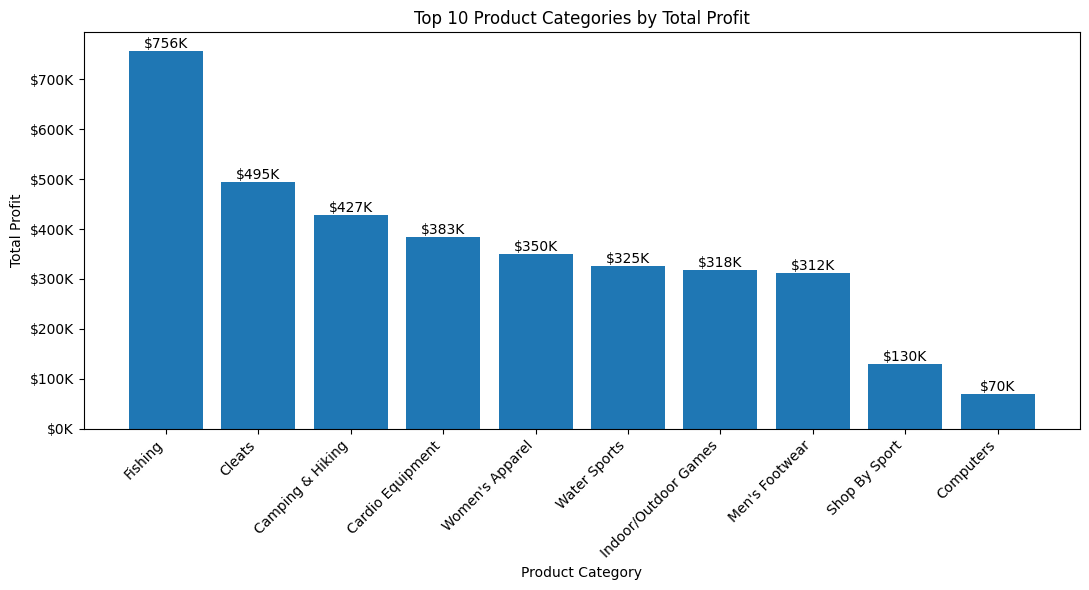

In [54]:
# Create bar chart showing the top 10 product categories by total profit

top_10_profit = category_profit_summary.head(10)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    top_10_profit['category_name'],
    top_10_profit['total_profit']
)

plt.title('Top 10 Product Categories by Total Profit')
plt.xlabel('Product Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')

# Format y-axis in thousands of dollars
plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${x/1_000:.0f}K')
)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'${height/1_000:.0f}K',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Chart Interpretation

Fishing generated the highest total profit among all product categories, with approximately \$756K in profit. This matches the sales analysis, where Fishing was also the highest-revenue category.

The top profit categories are very similar to the top sales categories, including Fishing, Cleats, Camping & Hiking, Cardio Equipment, Women's Apparel, Water Sports, Indoor/Outdoor Games, and Men's Footwear. This suggests that DataCo's strongest revenue categories are also contributing strongly to overall profit.

However, the size of the profit gap is important. Fishing generates substantially more profit than the other categories, making it a key product category for business performance. From a product and BI perspective, Fishing should be closely monitored because changes in its sales volume, profit margin, fulfillment performance, or customer experience could have an outsized impact on company results.

### 5.4 Average Profit Margin by Product Category

This analysis compares product categories by average profit margin. While total sales and total profit show which categories contribute the most overall business value, profit margin helps identify which categories are more efficient at turning revenue into profit.

In [55]:
# This table will show the categories with the highest average profit margin.
category_margin_summary = category_sales_summary.sort_values(
    by='avg_profit_margin_pct',
    ascending=False
)

category_margin_summary.head(10)

,category_name,total_orders,total_sales,total_profit,avg_profit_margin_pct,avg_discount_rate,late_delivery_rate_pct
23,Golf Bags & Carts,61,10369.39,1810.07,17.46,9.34,68.85
43,Toys,529,6104.66,900.71,14.75,10.17,55.01
48,Women's Clothing,650,140283.00,19102.85,13.62,10.20,56.46
19,Fitness Accessories,309,35601.44,5258.39,13.56,10.26,56.96
35,Men's Golf Clubs,283,47035.80,5517.99,13.17,9.91,47.70
39,Soccer,138,26477.05,3901.95,13.10,9.61,54.35
20,Garden,484,257768.73,33443.01,12.97,10.12,55.79
49,Women's Golf Clubs,181,44545.97,5028.64,12.93,10.17,53.59
36,Music,434,113122.10,14436.32,12.76,10.14,57.14
7,CDs,271,3059.59,383.85,12.55,10.15,52.03


### Profit Margin by Product Category Chart

The chart below shows the top 10 product categories by average profit margin. This helps identify categories that may be especially efficient or profitable relative to their sales volume.

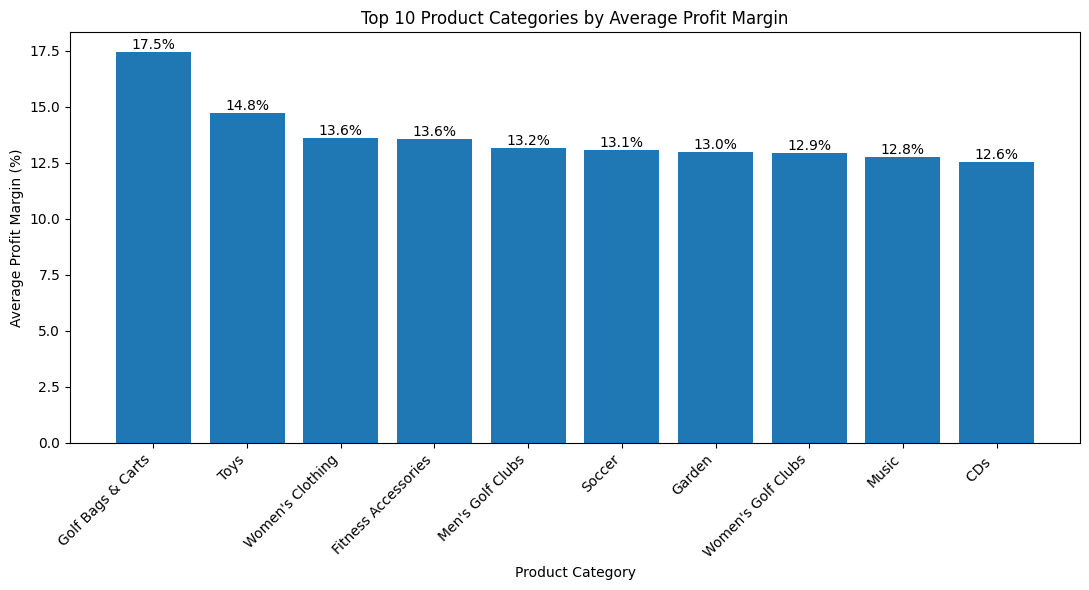

In [56]:
# Create bar chart showing the top 10 product categories by average profit margin

top_10_margin = category_margin_summary.head(10)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    top_10_margin['category_name'],
    top_10_margin['avg_profit_margin_pct']
)

plt.title('Top 10 Product Categories by Average Profit Margin')
plt.xlabel('Product Category')
plt.ylabel('Average Profit Margin (%)')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Chart Interpretation

Golf Bags & Carts had the highest average profit margin at 17.5%, making it the most efficient category at converting sales into profit among the categories shown. Toys, Women's Clothing, Fitness Accessories, and Men's Golf Clubs also had above-average profit margins compared with the major revenue-driving categories.

This result differs from the total sales and total profit analyses. The highest-sales categories, such as Fishing, Cleats, and Camping & Hiking, generated the most overall revenue and profit, but they were not the highest-margin categories.

From a product analytics perspective, this suggests that DataCo should evaluate product categories using multiple performance measures. High-sales categories are important because of their revenue impact, while high-margin categories may represent opportunities to improve profitability if sales volume can be increased.

Golf Bags & Carts is especially worth investigating because it combines strong average profit margin with high late delivery risk. Improving fulfillment performance in this category could help protect both profitability and customer experience.

### 5.5 High Margin Categories with Order Volume

This analysis compares average profit margin with order volume. The goal is to determine whether the highest-margin categories also have enough sales activity to represent meaningful business opportunities.

#### High-Margin Category Volume Check

A category with a high average profit margin may look attractive, but it may not be a major business opportunity if it has very low order volume. This table compares margin, order volume, total sales, and total profit for the highest-margin categories.

In [57]:
# Sort categories by average profit margin and review order volume

high_margin_volume_summary = category_sales_summary.sort_values(
    by='avg_profit_margin_pct',
    ascending=False
)

high_margin_volume_summary[
    [
        'category_name',
        'total_orders',
        'total_sales',
        'total_profit',
        'avg_profit_margin_pct',
        'avg_discount_rate',
        'late_delivery_rate_pct'
    ]
].head(10)

,category_name,total_orders,total_sales,total_profit,avg_profit_margin_pct,avg_discount_rate,late_delivery_rate_pct
23,Golf Bags & Carts,61,10369.39,1810.07,17.46,9.34,68.85
43,Toys,529,6104.66,900.71,14.75,10.17,55.01
48,Women's Clothing,650,140283.00,19102.85,13.62,10.20,56.46
19,Fitness Accessories,309,35601.44,5258.39,13.56,10.26,56.96
35,Men's Golf Clubs,283,47035.80,5517.99,13.17,9.91,47.70
39,Soccer,138,26477.05,3901.95,13.10,9.61,54.35
20,Garden,484,257768.73,33443.01,12.97,10.12,55.79
49,Women's Golf Clubs,181,44545.97,5028.64,12.93,10.17,53.59
36,Music,434,113122.10,14436.32,12.76,10.14,57.14
7,CDs,271,3059.59,383.85,12.55,10.15,52.03


In [58]:
# Create cleaner display table for high-margin categories

high_margin_volume_display = high_margin_volume_summary[
    [
        'category_name',
        'total_orders',
        'total_sales',
        'total_profit',
        'avg_profit_margin_pct',
        'avg_discount_rate',
        'late_delivery_rate_pct'
    ]
].head(10).copy()

high_margin_volume_display['total_sales'] = high_margin_volume_display['total_sales'].round(2)
high_margin_volume_display['total_profit'] = high_margin_volume_display['total_profit'].round(2)

high_margin_volume_display

,category_name,total_orders,total_sales,total_profit,avg_profit_margin_pct,avg_discount_rate,late_delivery_rate_pct
23,Golf Bags & Carts,61,10369.39,1810.07,17.46,9.34,68.85
43,Toys,529,6104.66,900.71,14.75,10.17,55.01
48,Women's Clothing,650,140283.00,19102.85,13.62,10.20,56.46
19,Fitness Accessories,309,35601.44,5258.39,13.56,10.26,56.96
35,Men's Golf Clubs,283,47035.80,5517.99,13.17,9.91,47.70
39,Soccer,138,26477.05,3901.95,13.10,9.61,54.35
20,Garden,484,257768.73,33443.01,12.97,10.12,55.79
49,Women's Golf Clubs,181,44545.97,5028.64,12.93,10.17,53.59
36,Music,434,113122.10,14436.32,12.76,10.14,57.14
7,CDs,271,3059.59,383.85,12.55,10.15,52.03


#### Margin and Order Volume Chart

The chart below compares average profit margin and total order volume for the top 10 highest-margin product categories. This helps show whether high-margin categories also have enough order activity to be meaningful for business strategy.

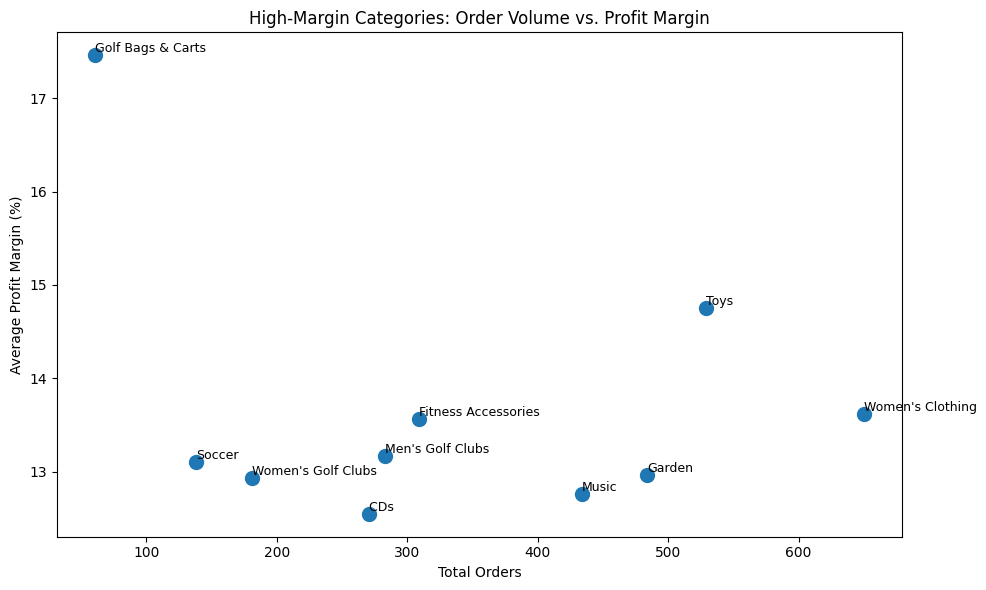

In [59]:
# Create scatter plot comparing order volume and average profit margin

top_10_margin_volume = high_margin_volume_summary.head(10)

plt.figure(figsize=(10, 6))

plt.scatter(
    top_10_margin_volume['total_orders'],
    top_10_margin_volume['avg_profit_margin_pct'],
    s=100
)

plt.title('High-Margin Categories: Order Volume vs. Profit Margin')
plt.xlabel('Total Orders')
plt.ylabel('Average Profit Margin (%)')

for i, row in top_10_margin_volume.iterrows():
    plt.text(
        row['total_orders'],
        row['avg_profit_margin_pct'],
        row['category_name'],
        fontsize=9,
        ha='left',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Chart Interpretation

The margin and order volume analysis shows that the highest-margin categories are not necessarily the highest-volume categories. Golf Bags & Carts had the highest average profit margin, but its order volume was very low compared with several other categories.

Women's Clothing and Toys appear to be stronger business opportunities because they combine relatively high profit margins with higher order volume among the high-margin categories. These categories may be worth further review for growth, merchandising, or promotional opportunities.

This analysis reinforces the importance of evaluating product performance using multiple metrics. A category can have a strong profit margin but still have limited business impact if order volume is low. From a product analytics perspective, DataCo should distinguish between high-margin niche categories and categories with both strong margins and meaningful customer demand.

### 5.6 Discount Rate and Profitability

This analysis explores the relationship between average discount rate and average profit margin across product categories. The goal is to determine whether categories with higher discounts tend to have weaker profitability.

#### Discount and Profitability Summary

The table below compares product categories by average discount rate, average profit margin, total sales, total profit, and order volume. This helps identify whether discounting may be affecting category profitability.

In [60]:
# Create discount and profitability summary by product category

discount_profit_summary = (
    df_clean
    .groupby('category_name')
    .agg(
        total_orders=('order_id', 'count'),
        total_sales=('sales', 'sum'),
        total_profit=('order_profit_per_order', 'sum'),
        avg_discount_rate=('order_item_discount_rate', 'mean'),
        avg_profit_margin_pct=('profit_margin_pct', 'mean'),
        late_delivery_rate_pct=('is_late_delivery', lambda x: x.mean() * 100)
    )
    .reset_index()
)

discount_profit_summary['avg_discount_rate_pct'] = (
    discount_profit_summary['avg_discount_rate'] * 100
).round(2)

discount_profit_summary['avg_profit_margin_pct'] = (
    discount_profit_summary['avg_profit_margin_pct']
).round(2)

discount_profit_summary['total_sales'] = discount_profit_summary['total_sales'].round(2)
discount_profit_summary['total_profit'] = discount_profit_summary['total_profit'].round(2)
discount_profit_summary['late_delivery_rate_pct'] = discount_profit_summary['late_delivery_rate_pct'].round(2)

discount_profit_summary = discount_profit_summary.sort_values(
    by='avg_discount_rate_pct',
    ascending=False
)

discount_profit_summary[
    [
        'category_name',
        'total_orders',
        'total_sales',
        'total_profit',
        'avg_discount_rate_pct',
        'avg_profit_margin_pct',
        'late_delivery_rate_pct'
    ]
].head(10)

,category_name,total_orders,total_sales,total_profit,avg_discount_rate_pct,avg_profit_margin_pct,late_delivery_rate_pct
1,As Seen on TV!,68,20597.94,714.43,10.94,5.50,57.35
26,Golf Shoes,524,107998.00,12406.07,10.56,10.84,55.53
41,Strength Training,111,54895.53,332.31,10.50,5.13,57.66
29,Hunting & Shooting,440,56848.42,5980.00,10.47,8.25,56.14
2,Baby,207,12229.56,1525.03,10.43,12.47,52.66
0,Accessories,1780,133671.51,16643.52,10.38,11.96,56.97
6,Boxing & MMA,423,85205.41,8641.37,10.37,10.06,56.26
3,Baseball & Softball,632,94057.15,12762.13,10.29,12.34,55.22
33,Men's Clothing,208,43856.80,2006.04,10.27,4.57,54.33
19,Fitness Accessories,309,35601.44,5258.39,10.26,13.56,56.96


#### Discount Rate vs. Profit Margin Chart

The scatter plot below compares average discount rate and average profit margin by product category. Each point represents a product category. This visualization helps show whether categories with higher discounts tend to have lower profit margins.

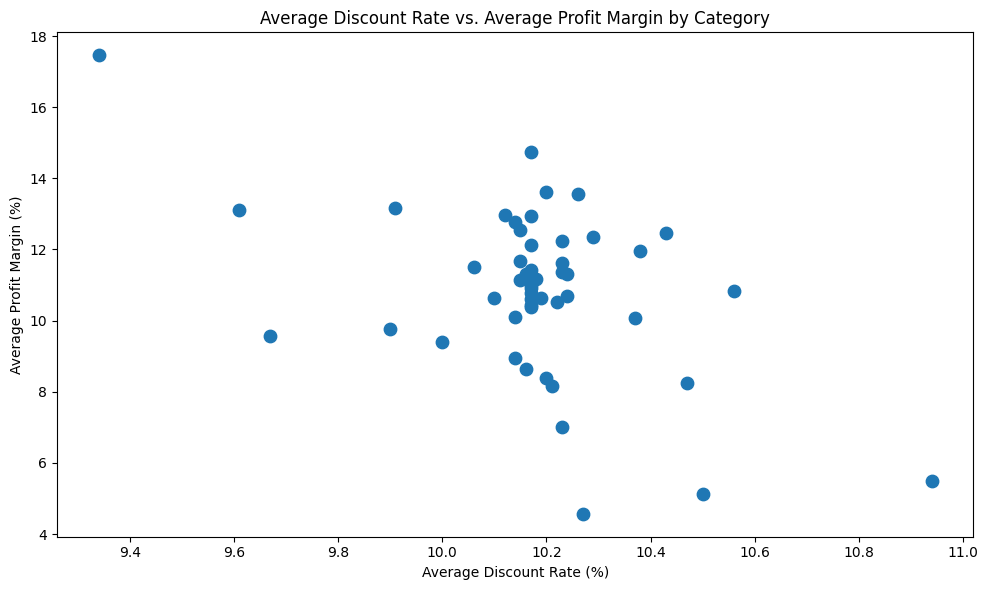

In [61]:
# Create scatter plot comparing average discount rate and average profit margin

plt.figure(figsize=(10, 6))

plt.scatter(
    discount_profit_summary['avg_discount_rate_pct'],
    discount_profit_summary['avg_profit_margin_pct'],
    s=80
)

plt.title('Average Discount Rate vs. Average Profit Margin by Category')
plt.xlabel('Average Discount Rate (%)')
plt.ylabel('Average Profit Margin (%)')

plt.tight_layout()
plt.show()

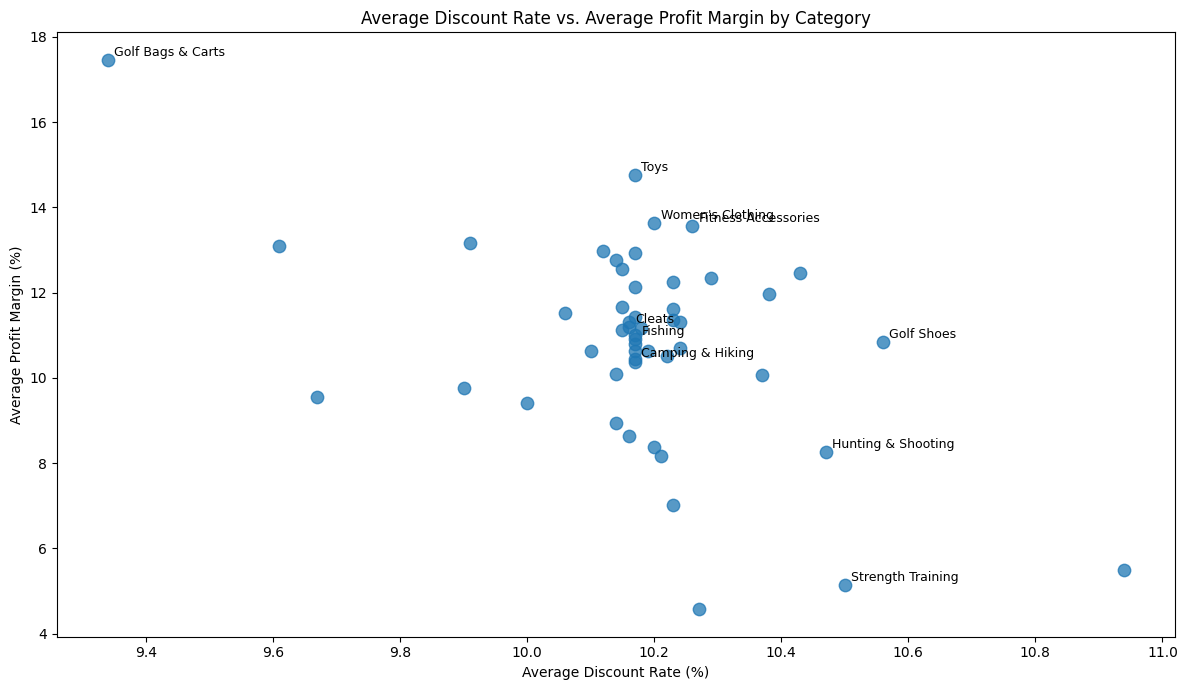

In [64]:
# Cleaner scatter plot with manually selected labels

categories_to_label = [
    'Golf Bags & Carts',
    'Toys',
    "Women's Clothing",
    'Fitness Accessories',
    'As Seen on TV!',
    'Strength Training',
    'Hunting & Shooting',
    'Golf Shoes',
    'Fishing',
    'Cleats',
    'Camping & Hiking'
]

plt.figure(figsize=(12, 7))

plt.scatter(
    discount_profit_summary['avg_discount_rate_pct'],
    discount_profit_summary['avg_profit_margin_pct'],
    s=80,
    alpha=0.75
)

plt.title('Average Discount Rate vs. Average Profit Margin by Category')
plt.xlabel('Average Discount Rate (%)')
plt.ylabel('Average Profit Margin (%)')

for i, row in discount_profit_summary.iterrows():
    if row['category_name'] in categories_to_label:
        plt.text(
            row['avg_discount_rate_pct'] + 0.01,
            row['avg_profit_margin_pct'] + 0.1,
            row['category_name'],
            fontsize=9
        )

plt.tight_layout()
plt.show()

#### Chart Interpretation

The scatter plot shows that most product categories are clustered around an average discount rate of approximately 10% to 10.4%, but their profit margins vary more widely. This suggests that discount rate alone may not fully explain differences in category profitability.

Golf Bags & Carts stands out with the highest average profit margin and one of the lower average discount rates. Toys, Women's Clothing, and Fitness Accessories also show relatively strong profit margins. On the lower-margin side, categories such as Strength Training and Hunting & Shooting have weaker average profit margins despite having discount rates near or above the category average.

This analysis suggests that profitability may be influenced by additional factors beyond discounting, such as product cost structure, pricing strategy, fulfillment costs, or category-level demand. The correlation value provides a more direct measure of whether discount rate and profit margin are strongly related.

In [65]:
corr_value = discount_profit_summary['avg_discount_rate_pct'].corr(
    discount_profit_summary['avg_profit_margin_pct']
)

print(f"Correlation between average discount rate and average profit margin: {corr_value:.2f}")

Correlation between average discount rate and average profit margin: -0.50


#### Correlation Interpretation

The correlation between average discount rate and average profit margin is -0.50. This indicates a moderate negative relationship between discounting and profitability across product categories.

In general, categories with higher average discount rates tend to have lower average profit margins. This suggests that discounting may be contributing to weaker profitability in some categories, although other factors such as product cost, pricing strategy, fulfillment costs, and demand patterns may also influence margins.

From a business perspective, DataCo should review categories with higher discount rates and lower profit margins to determine whether discounts are generating enough sales volume to justify the margin tradeoff. Categories such as Strength Training, Hunting & Shooting, and As Seen on TV! may be worth closer review because they appear to have weaker margins despite relatively high discount rates.

Because this analysis is based on category-level averages, the results should be interpreted as directional rather than causal. A deeper analysis at the order or product level would be needed to determine whether discounts directly reduce profitability.

## Part 5 Summary

The product and profitability analysis shows that DataCo’s revenue and profit are concentrated in a relatively small group of product categories. Fishing was the strongest category overall, generating approximately \$6.9 million in sales and \$756K in profit. Cleats and Camping & Hiking were also major contributors to both sales and profit.

The highest-sales categories were also generally the highest-profit categories, which suggests that DataCo’s major revenue drivers are also contributing meaningfully to overall profitability. However, average profit margin analysis showed a different pattern. Some categories with the highest margins, such as Golf Bags & Carts, Toys, Women’s Clothing, and Fitness Accessories, were not necessarily the highest-volume categories.

This distinction is important because high sales, high profit, and high margin do not always point to the same product categories. High-sales categories should be monitored because they have the largest business impact, while high-margin categories may represent opportunities for growth if demand can be increased.

The discount analysis showed a moderate negative relationship between average discount rate and average profit margin, with a correlation of -0.50. This suggests that higher discounting may be associated with weaker profitability across product categories. However, this relationship should be interpreted as directional rather than causal because other factors, such as product cost, pricing strategy, fulfillment costs, and demand patterns, may also affect profit margins.

Overall, DataCo should prioritize major revenue and profit drivers such as Fishing, Cleats, and Camping & Hiking, while also investigating high-margin but lower-volume categories such as Golf Bags & Carts and Toys. Categories with higher discounts and weaker margins should be reviewed to determine whether discounting is producing enough sales volume to justify the margin tradeoff.

## Part 6: Operations and Fulfillment Analysis

In this section, I analyze order status, fulfillment patterns, and operational risk. The goal is to understand how order outcomes such as completed, pending, canceled, or suspected fraud may affect sales, profit, and customer experience.

While Parts 4 and 5 focused on delivery performance and product profitability, Part 6 focuses on operational outcomes. This helps identify whether certain order statuses or fulfillment patterns are creating business risk.

### 6.1 Order Status Distribution

This analysis reviews the number of orders in each order status. The goal is to understand how orders are distributed across completed, pending, canceled, and other fulfillment outcomes.

In [66]:
order_status_summary = (
    df_clean
    .groupby('order_status')
    .agg(
        total_orders=('order_id', 'count'),
        total_sales=('sales', 'sum'),
        total_profit=('order_profit_per_order', 'sum'),
        avg_shipping_delay=('shipping_delay_days', 'mean'),
        late_delivery_rate_pct=('is_late_delivery', lambda x: x.mean() * 100)
    )
    .reset_index()
)

order_status_summary['order_share_pct'] = (
    order_status_summary['total_orders'] / order_status_summary['total_orders'].sum() * 100
).round(2)

order_status_summary['total_sales'] = order_status_summary['total_sales'].round(2)
order_status_summary['total_profit'] = order_status_summary['total_profit'].round(2)
order_status_summary['avg_shipping_delay'] = order_status_summary['avg_shipping_delay'].round(2)
order_status_summary['late_delivery_rate_pct'] = order_status_summary['late_delivery_rate_pct'].round(2)

order_status_summary = order_status_summary.sort_values(
    by='total_orders',
    ascending=False
)

order_status_summary

,order_status,total_orders,total_sales,total_profit,avg_shipping_delay,late_delivery_rate_pct,order_share_pct
2,COMPLETE,59491,12095314.95,1321735.75,0.56,57.49,32.96
6,PENDING_PAYMENT,39832,8106697.56,843810.24,0.59,57.55,22.07
7,PROCESSING,21902,4504063.75,494825.87,0.56,57.09,12.13
5,PENDING,20227,4120532.87,435725.85,0.57,57.90,11.20
1,CLOSED,19616,4022624.17,457981.09,0.55,56.63,10.87
3,ON_HOLD,9804,1981542.71,208913.04,0.53,55.59,5.43
8,SUSPECTED_FRAUD,4062,825934.96,85136.71,0.59,0.00,2.25
0,CANCELED,3692,744370.40,75345.63,0.56,0.00,2.05
4,PAYMENT_REVIEW,1893,383653.66,43428.79,0.60,57.16,1.05


#### Order Status Distribution Chart

The chart below shows the number of orders by order status. This helps identify which fulfillment outcomes are most common and whether a meaningful share of orders are canceled, pending, or flagged for review.

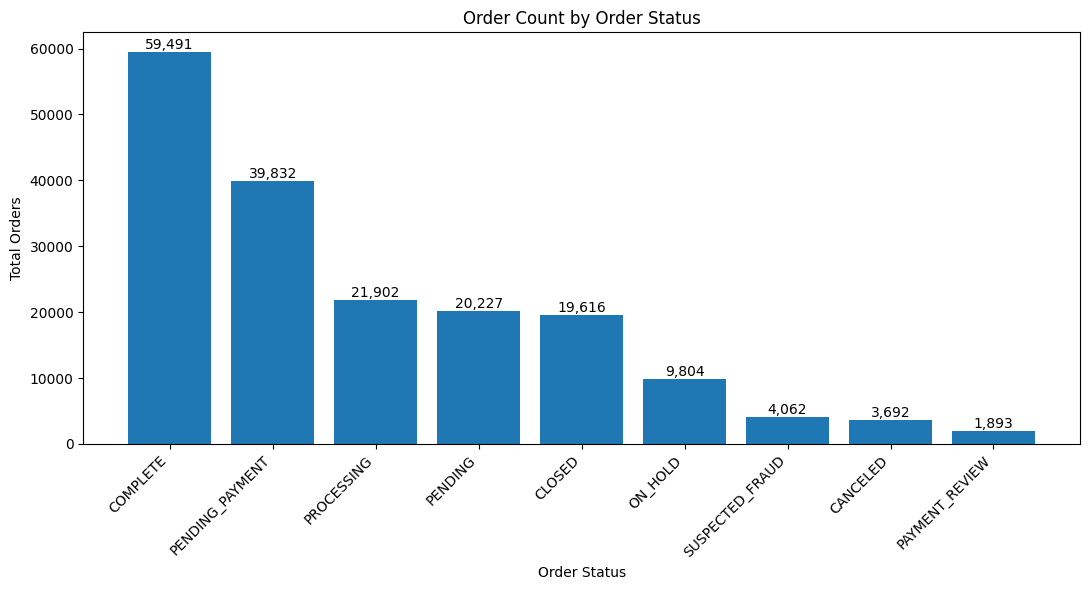

In [67]:
# Create bar chart showing order count by order status

plt.figure(figsize=(11, 6))

bars = plt.bar(
    order_status_summary['order_status'],
    order_status_summary['total_orders']
)

plt.title('Order Count by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Total Orders')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Chart Interpretation

The order status distribution shows that COMPLETE is the most common order status, with 59,491 orders. However, a large number of orders are also found in non-completed or unresolved statuses, including PENDING_PAYMENT, PROCESSING, PENDING, ON_HOLD, SUSPECTED_FRAUD, CANCELED, and PAYMENT_REVIEW.

This suggests that DataCo has a meaningful volume of orders that may require additional operational follow-up before they are fully completed. PENDING_PAYMENT is especially important because it represents the second-largest order status group, with 39,832 orders.

From an operations perspective, DataCo should monitor unresolved order statuses closely because delays in payment, processing, fraud review, or cancellation workflows may affect fulfillment efficiency, revenue recognition, and customer experience.

In [69]:
# Calculate the share of orders by status
order_status_summary[
    [
        'order_status',
        'total_orders',
        'order_share_pct',
        'total_sales',
        'total_profit',
        'late_delivery_rate_pct'
    ]
]

,order_status,total_orders,order_share_pct,total_sales,total_profit,late_delivery_rate_pct
2,COMPLETE,59491,32.96,12095314.95,1321735.75,57.49
6,PENDING_PAYMENT,39832,22.07,8106697.56,843810.24,57.55
7,PROCESSING,21902,12.13,4504063.75,494825.87,57.09
5,PENDING,20227,11.20,4120532.87,435725.85,57.90
1,CLOSED,19616,10.87,4022624.17,457981.09,56.63
3,ON_HOLD,9804,5.43,1981542.71,208913.04,55.59
8,SUSPECTED_FRAUD,4062,2.25,825934.96,85136.71,0.00
0,CANCELED,3692,2.05,744370.40,75345.63,0.00
4,PAYMENT_REVIEW,1893,1.05,383653.66,43428.79,57.16


#### Order Status Share Interpretation

Only 32.96% of orders are marked as COMPLETE, while a large share of orders are in pending, processing, closed, on-hold, review, canceled, or suspected fraud statuses. PENDING_PAYMENT is the second-largest group, accounting for 22.07% of all orders.

This suggests that DataCo has a meaningful amount of order volume tied to statuses that may require additional operational review or follow-up. These statuses may affect fulfillment efficiency, revenue recognition, customer communication, and overall customer experience.

COMPLETE, PENDING_PAYMENT, PROCESSING, PENDING, and CLOSED account for the majority of total sales and profit. This means operational improvements in payment processing, order review, and fulfillment workflows could have a meaningful business impact.

SUSPECTED_FRAUD and CANCELED orders show a 0.00% late delivery rate, which is expected because these orders likely did not move through the normal fulfillment and delivery process.

Because these statuses are not directly comparable to completed or actively fulfilled orders, they should be reviewed separately in future delivery-specific analysis. When measuring true shipping performance, canceled and suspected fraud orders may need to be filtered out to avoid understating or distorting late delivery rates.

### 6.2 Sales and Profit by Order Status

This analysis compares total sales and total profit across order statuses. The goal is to understand how much business value is tied to completed, pending, canceled, fraud review, and other fulfillment outcomes.

#### Sales and Profit Summary by Order Status

The table below shows total orders, total sales, total profit, order share, and late delivery rate by order status. This helps identify which statuses represent the greatest business value and which may create operational or financial risk.

In [70]:
# Create sales and profit summary by order status

order_status_value_summary = order_status_summary[
    [
        'order_status',
        'total_orders',
        'order_share_pct',
        'total_sales',
        'total_profit',
        'avg_shipping_delay',
        'late_delivery_rate_pct'
    ]
].copy()

order_status_value_summary = order_status_value_summary.sort_values(
    by='total_sales',
    ascending=False
)

order_status_value_summary

,order_status,total_orders,order_share_pct,total_sales,total_profit,avg_shipping_delay,late_delivery_rate_pct
2,COMPLETE,59491,32.96,12095314.95,1321735.75,0.56,57.49
6,PENDING_PAYMENT,39832,22.07,8106697.56,843810.24,0.59,57.55
7,PROCESSING,21902,12.13,4504063.75,494825.87,0.56,57.09
5,PENDING,20227,11.20,4120532.87,435725.85,0.57,57.90
1,CLOSED,19616,10.87,4022624.17,457981.09,0.55,56.63
3,ON_HOLD,9804,5.43,1981542.71,208913.04,0.53,55.59
8,SUSPECTED_FRAUD,4062,2.25,825934.96,85136.71,0.59,0.00
0,CANCELED,3692,2.05,744370.40,75345.63,0.56,0.00
4,PAYMENT_REVIEW,1893,1.05,383653.66,43428.79,0.60,57.16


#### Sales by Order Status Chart

The chart below shows total sales by order status. This helps identify which fulfillment outcomes represent the largest share of revenue and where operational delays or unresolved statuses may have the greatest business impact.

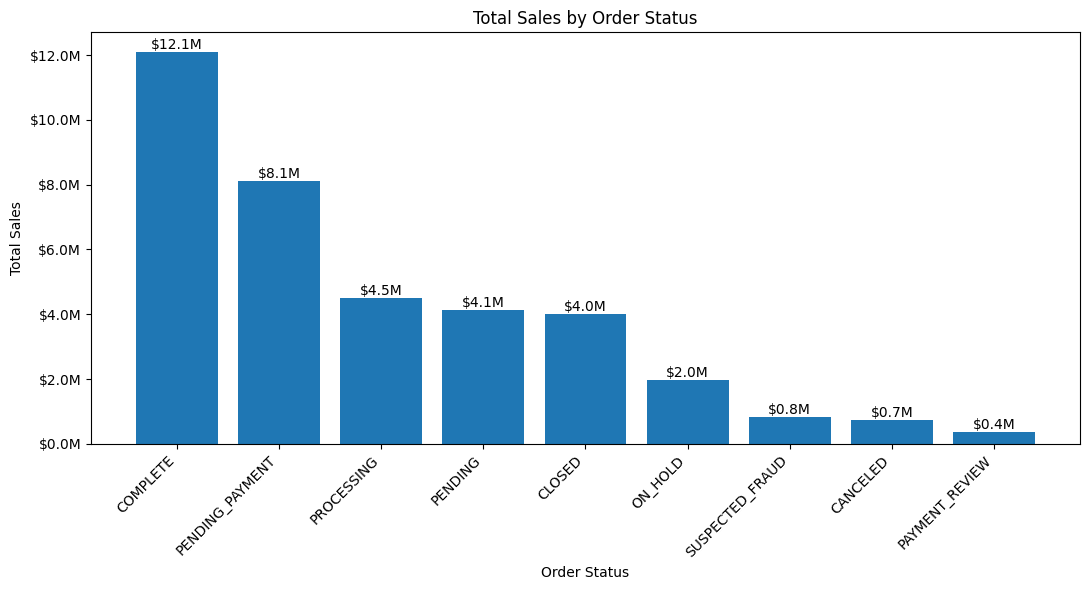

In [71]:
# Create bar chart showing total sales by order status

import matplotlib.ticker as mtick

plt.figure(figsize=(11, 6))

bars = plt.bar(
    order_status_value_summary['order_status'],
    order_status_value_summary['total_sales']
)

plt.title('Total Sales by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${x/1_000_000:.1f}M')
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'${height/1_000_000:.1f}M',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Sales by Order Status Interpretation

COMPLETE orders generated the highest total sales, with approximately \$12.1 million in revenue. However, a substantial amount of revenue is also tied to non-completed or unresolved statuses.

PENDING_PAYMENT generated approximately \$8.1 million in sales, making it the second-largest order status by revenue. PROCESSING, PENDING, and CLOSED each represented approximately \$4.0 million to \$4.5 million in sales.

From an operations perspective, this suggests that a meaningful amount of business value is tied to orders that may still require payment completion, processing, fulfillment, or status resolution. Improving workflows around pending payment, processing, and pending orders could help DataCo reduce operational bottlenecks and improve revenue flow.

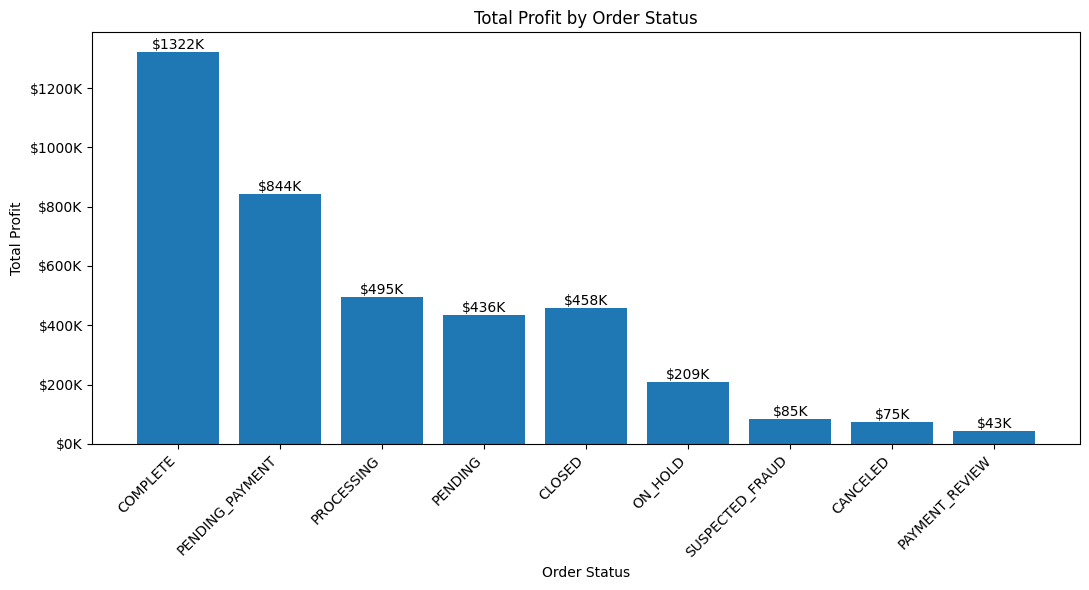

In [72]:
# Create bar chart showing total profit by order status

plt.figure(figsize=(11, 6))

bars = plt.bar(
    order_status_value_summary['order_status'],
    order_status_value_summary['total_profit']
)

plt.title('Total Profit by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')

plt.gca().yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, _: f'${x/1_000:.0f}K')
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'${height/1_000:.0f}K',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Profit by Order Status Interpretation

COMPLETE orders generated the highest total profit, with approximately \$1.32 million in profit. PENDING_PAYMENT was the second-largest profit contributor at approximately \$844K, followed by PROCESSING, CLOSED, and PENDING.

The profit pattern is similar to the sales pattern, suggesting that the order statuses generating the most revenue are also contributing the most profit. However, a meaningful amount of profit is tied to unresolved or non-final statuses such as PENDING_PAYMENT, PROCESSING, PENDING, and ON_HOLD.

From an operations perspective, this reinforces the importance of monitoring order status workflows. Improving payment completion, order processing, and hold-resolution processes could help DataCo reduce operational friction and improve revenue and profit realization.

#### 6.2 Key Takeaway

Sales and profit are highest for COMPLETE orders, but a significant amount of business value is also tied to orders that are not fully resolved. PENDING_PAYMENT is especially important because it represents both the second-highest order count and the second-highest sales and profit totals.

This suggests that order status management is not only an operational issue, but also a financial performance issue.

### 6.3 Operational Risk by Order Status

This analysis compares operational risk across order statuses using late delivery rate, average shipping delay, order share, sales, and profit. The goal is to identify which statuses may create the greatest fulfillment or customer experience risk.

#### Operational Risk Summary by Order Status

The table below compares order statuses by late delivery rate and average shipping delay. This helps identify whether certain statuses are more associated with fulfillment risk or delayed shipping performance.

In [73]:
# Create operational risk summary by order status

order_status_risk_summary = order_status_summary[
    [
        'order_status',
        'total_orders',
        'order_share_pct',
        'avg_shipping_delay',
        'late_delivery_rate_pct',
        'total_sales',
        'total_profit'
    ]
].copy()

order_status_risk_summary = order_status_risk_summary.sort_values(
    by='late_delivery_rate_pct',
    ascending=False
)

order_status_risk_summary

,order_status,total_orders,order_share_pct,avg_shipping_delay,late_delivery_rate_pct,total_sales,total_profit
5,PENDING,20227,11.20,0.57,57.90,4120532.87,435725.85
6,PENDING_PAYMENT,39832,22.07,0.59,57.55,8106697.56,843810.24
2,COMPLETE,59491,32.96,0.56,57.49,12095314.95,1321735.75
4,PAYMENT_REVIEW,1893,1.05,0.60,57.16,383653.66,43428.79
7,PROCESSING,21902,12.13,0.56,57.09,4504063.75,494825.87
1,CLOSED,19616,10.87,0.55,56.63,4022624.17,457981.09
3,ON_HOLD,9804,5.43,0.53,55.59,1981542.71,208913.04
8,SUSPECTED_FRAUD,4062,2.25,0.59,0.00,825934.96,85136.71
0,CANCELED,3692,2.05,0.56,0.00,744370.40,75345.63


#### Late Delivery Rate by Order Status Chart

The chart below compares late delivery rates across order statuses. This helps identify which order outcomes are most associated with late delivery risk.

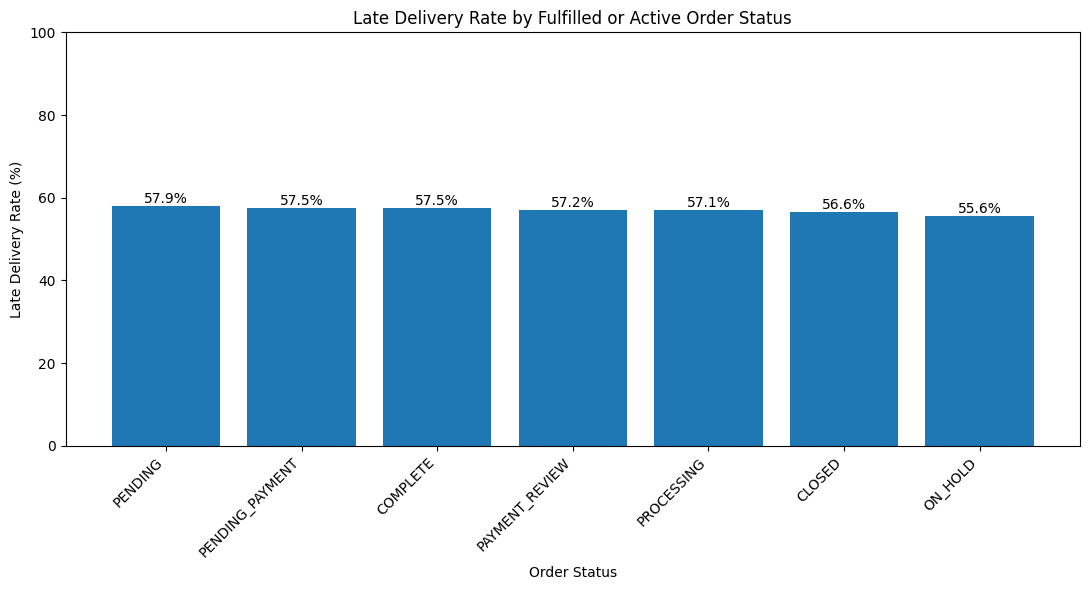

In [75]:
# Filter out statuses that are not comparable to normal fulfilled or active orders

fulfilled_status_risk = order_status_risk_summary[
    ~order_status_risk_summary['order_status'].isin(['CANCELED', 'SUSPECTED_FRAUD'])
].copy()

plt.figure(figsize=(11, 6))

bars = plt.bar(
    fulfilled_status_risk['order_status'],
    fulfilled_status_risk['late_delivery_rate_pct']
)

plt.title('Late Delivery Rate by Fulfilled or Active Order Status')
plt.xlabel('Order Status')
plt.ylabel('Late Delivery Rate (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Chart Interpretation

After removing CANCELED and SUSPECTED_FRAUD orders, late delivery rates are fairly similar across active or fulfilled order statuses. PENDING had the highest late delivery rate at 57.9%, followed by PENDING_PAYMENT and COMPLETE at 57.5%.

The difference between the highest and lowest active statuses is relatively small, ranging from 55.6% to 57.9%. This suggests that order status alone does not strongly explain late delivery risk among active or fulfilled orders.

From an operations perspective, this reinforces the earlier finding that late delivery appears to be a broader fulfillment issue rather than a problem isolated to one specific order status. However, because PENDING_PAYMENT and PENDING represent large order volumes, they should still be monitored closely as part of operational workflow management.

#### Average Shipping Delay by Order Status

The chart below compares average shipping delay by order status. This helps identify whether certain statuses are associated with longer delays compared with the scheduled shipping timeline.

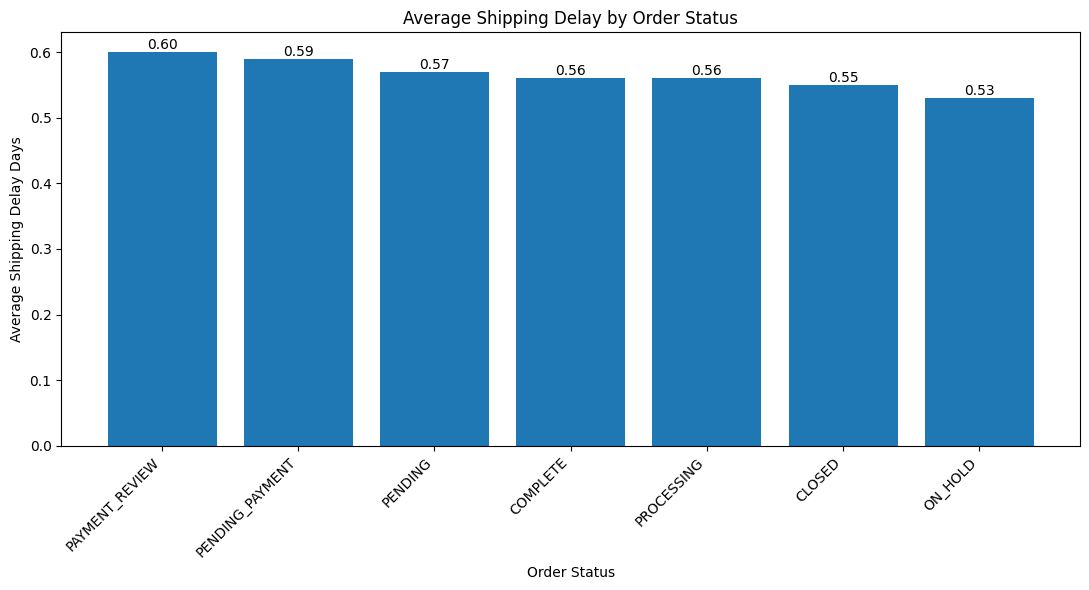

In [76]:
# Create bar chart showing average shipping delay by order status

fulfilled_status_delay = fulfilled_status_risk.sort_values(
    by='avg_shipping_delay',
    ascending=False
)

plt.figure(figsize=(11, 6))

bars = plt.bar(
    fulfilled_status_delay['order_status'],
    fulfilled_status_delay['avg_shipping_delay']
)

plt.title('Average Shipping Delay by Order Status')
plt.xlabel('Order Status')
plt.ylabel('Average Shipping Delay Days')
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

#### Chart Interpretation

Average shipping delay is fairly consistent across active or fulfilled order statuses. PAYMENT_REVIEW had the highest average shipping delay at 0.60 days, followed by PENDING_PAYMENT at 0.59 days and PENDING at 0.57 days.

However, the differences between statuses are small. The range from the highest to lowest average delay is only 0.07 days, suggesting that order status is not a major driver of shipping delay severity.

This supports the broader pattern seen throughout the operations analysis: late delivery and shipping delay appear to be system-wide fulfillment issues rather than problems tied to one specific order status. From an operations perspective, DataCo may benefit more from reviewing shipping mode expectations, fulfillment timelines, and end-to-end processing efficiency than from focusing only on individual order statuses.

#### 6.3 Key Takeaway

Operational risk by order status is relatively consistent among active and fulfilled orders. While PENDING, PENDING_PAYMENT, and PAYMENT_REVIEW show slightly higher delivery risk or delay, the differences are not large enough to suggest that order status is the primary cause of late delivery.

This reinforces the earlier finding that shipping mode and fulfillment expectations are likely stronger areas for deeper operational review.

### 6.4 Fulfillment Risk Summary

This analysis combines order volume, sales, profit, late delivery rate, and average shipping delay to identify which order statuses may deserve the most operational attention. The goal is to create a concise risk summary that can support business recommendations.

#### Fulfillment Risk Scorecard

The table below summarizes key operational risk indicators by order status. This scorecard helps compare order statuses across both business value and fulfillment risk.

In [77]:
# Create fulfillment risk scorecard by order status

fulfillment_risk_scorecard = fulfilled_status_risk[
    [
        'order_status',
        'total_orders',
        'order_share_pct',
        'total_sales',
        'total_profit',
        'late_delivery_rate_pct',
        'avg_shipping_delay'
    ]
].copy()

fulfillment_risk_scorecard = fulfillment_risk_scorecard.sort_values(
    by=['order_share_pct', 'late_delivery_rate_pct'],
    ascending=False
)

fulfillment_risk_scorecard

,order_status,total_orders,order_share_pct,total_sales,total_profit,late_delivery_rate_pct,avg_shipping_delay
2,COMPLETE,59491,32.96,12095314.95,1321735.75,57.49,0.56
6,PENDING_PAYMENT,39832,22.07,8106697.56,843810.24,57.55,0.59
7,PROCESSING,21902,12.13,4504063.75,494825.87,57.09,0.56
5,PENDING,20227,11.20,4120532.87,435725.85,57.90,0.57
1,CLOSED,19616,10.87,4022624.17,457981.09,56.63,0.55
3,ON_HOLD,9804,5.43,1981542.71,208913.04,55.59,0.53
4,PAYMENT_REVIEW,1893,1.05,383653.66,43428.79,57.16,0.60


In [78]:
# Create cleaner display version

fulfillment_risk_display = fulfillment_risk_scorecard.copy()

fulfillment_risk_display['total_sales'] = fulfillment_risk_display['total_sales'].round(2)
fulfillment_risk_display['total_profit'] = fulfillment_risk_display['total_profit'].round(2)
fulfillment_risk_display['late_delivery_rate_pct'] = fulfillment_risk_display['late_delivery_rate_pct'].round(2)
fulfillment_risk_display['avg_shipping_delay'] = fulfillment_risk_display['avg_shipping_delay'].round(2)

fulfillment_risk_display

,order_status,total_orders,order_share_pct,total_sales,total_profit,late_delivery_rate_pct,avg_shipping_delay
2,COMPLETE,59491,32.96,12095314.95,1321735.75,57.49,0.56
6,PENDING_PAYMENT,39832,22.07,8106697.56,843810.24,57.55,0.59
7,PROCESSING,21902,12.13,4504063.75,494825.87,57.09,0.56
5,PENDING,20227,11.20,4120532.87,435725.85,57.90,0.57
1,CLOSED,19616,10.87,4022624.17,457981.09,56.63,0.55
3,ON_HOLD,9804,5.43,1981542.71,208913.04,55.59,0.53
4,PAYMENT_REVIEW,1893,1.05,383653.66,43428.79,57.16,0.60


#### Operational Priority Categories

To make the scorecard easier to interpret, I created an operational priority label based on order share and late delivery rate. Statuses with both meaningful order volume and above-average late delivery rates are flagged as higher priority for review.

In [79]:
# Create operational priority labels

avg_order_share = fulfillment_risk_scorecard['order_share_pct'].mean()
avg_late_rate = fulfillment_risk_scorecard['late_delivery_rate_pct'].mean()

fulfillment_risk_scorecard['operational_priority'] = fulfillment_risk_scorecard.apply(
    lambda row: 'High Priority'
    if row['order_share_pct'] >= avg_order_share and row['late_delivery_rate_pct'] >= avg_late_rate
    else 'Moderate Priority'
    if row['order_share_pct'] >= avg_order_share or row['late_delivery_rate_pct'] >= avg_late_rate
    else 'Lower Priority',
    axis=1
)

fulfillment_risk_scorecard[
    [
        'order_status',
        'total_orders',
        'order_share_pct',
        'total_sales',
        'total_profit',
        'late_delivery_rate_pct',
        'avg_shipping_delay',
        'operational_priority'
    ]
].sort_values(
    by=['operational_priority', 'order_share_pct'],
    ascending=[True, False]
)

,order_status,total_orders,order_share_pct,total_sales,total_profit,late_delivery_rate_pct,avg_shipping_delay,operational_priority
2,COMPLETE,59491,32.96,12095314.95,1321735.75,57.49,0.56,High Priority
6,PENDING_PAYMENT,39832,22.07,8106697.56,843810.24,57.55,0.59,High Priority
1,CLOSED,19616,10.87,4022624.17,457981.09,56.63,0.55,Lower Priority
3,ON_HOLD,9804,5.43,1981542.71,208913.04,55.59,0.53,Lower Priority
7,PROCESSING,21902,12.13,4504063.75,494825.87,57.09,0.56,Moderate Priority
5,PENDING,20227,11.20,4120532.87,435725.85,57.90,0.57,Moderate Priority
4,PAYMENT_REVIEW,1893,1.05,383653.66,43428.79,57.16,0.60,Moderate Priority


In [80]:
# Sort priority labels in a business-friendly order

priority_order = {
    'High Priority': 1,
    'Moderate Priority': 2,
    'Lower Priority': 3
}

fulfillment_risk_scorecard['priority_sort'] = fulfillment_risk_scorecard['operational_priority'].map(priority_order)

fulfillment_risk_priority_display = fulfillment_risk_scorecard[
    [
        'order_status',
        'total_orders',
        'order_share_pct',
        'total_sales',
        'total_profit',
        'late_delivery_rate_pct',
        'avg_shipping_delay',
        'operational_priority',
        'priority_sort'
    ]
].sort_values(
    by=['priority_sort', 'order_share_pct'],
    ascending=[True, False]
).drop(columns='priority_sort')

fulfillment_risk_priority_display

,order_status,total_orders,order_share_pct,total_sales,total_profit,late_delivery_rate_pct,avg_shipping_delay,operational_priority
2,COMPLETE,59491,32.96,12095314.95,1321735.75,57.49,0.56,High Priority
6,PENDING_PAYMENT,39832,22.07,8106697.56,843810.24,57.55,0.59,High Priority
7,PROCESSING,21902,12.13,4504063.75,494825.87,57.09,0.56,Moderate Priority
5,PENDING,20227,11.20,4120532.87,435725.85,57.90,0.57,Moderate Priority
4,PAYMENT_REVIEW,1893,1.05,383653.66,43428.79,57.16,0.60,Moderate Priority
1,CLOSED,19616,10.87,4022624.17,457981.09,56.63,0.55,Lower Priority
3,ON_HOLD,9804,5.43,1981542.71,208913.04,55.59,0.53,Lower Priority


#### Operational Priority by Order Status

The chart below compares order share across active or fulfilled order statuses. Late delivery rates are shown as labels to provide additional fulfillment-risk context.

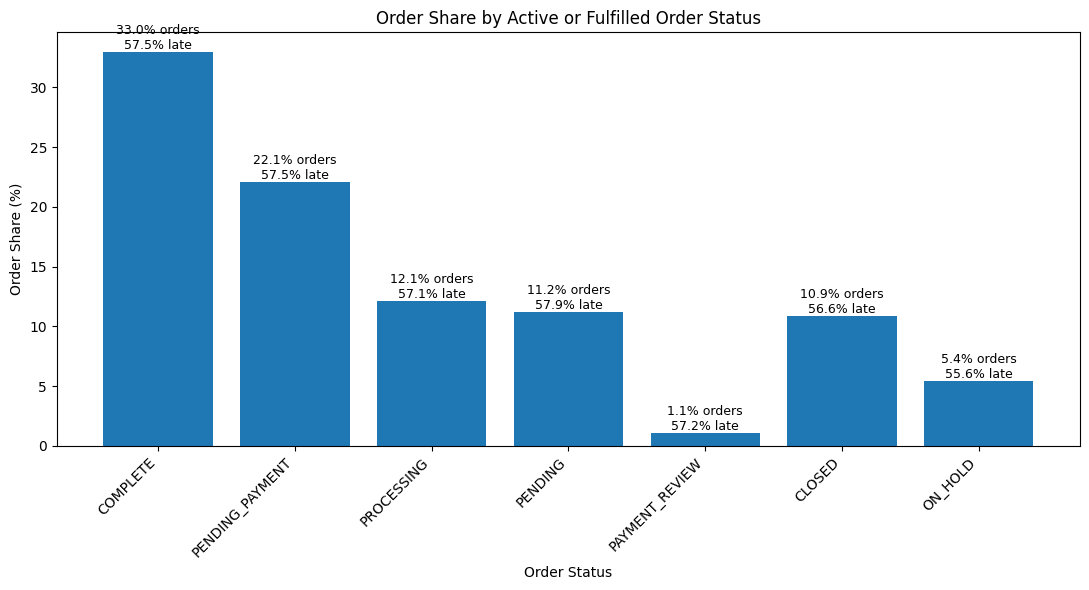

In [81]:
# Create chart showing order share by status with late delivery rate labels

plt.figure(figsize=(11, 6))

bars = plt.bar(
    fulfillment_risk_priority_display['order_status'],
    fulfillment_risk_priority_display['order_share_pct']
)

plt.title('Order Share by Active or Fulfilled Order Status')
plt.xlabel('Order Status')
plt.ylabel('Order Share (%)')
plt.xticks(rotation=45, ha='right')

for bar, late_rate in zip(
    bars,
    fulfillment_risk_priority_display['late_delivery_rate_pct']
):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}% orders\n{late_rate:.1f}% late',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### Chart Interpretation

The operational priority chart shows that COMPLETE orders make up the largest share of active or fulfilled orders at 33.0%, followed by PENDING_PAYMENT at 22.1%. These two statuses also have similar late delivery rates of 57.5%.

Although late delivery rates are fairly consistent across statuses, the order share varies significantly. This means COMPLETE and PENDING_PAYMENT deserve the most operational attention because they represent the largest portions of order volume and business activity.

PENDING_PAYMENT is especially important because it combines high order share, high sales, high profit, and a late delivery rate similar to completed orders. From an operations perspective, improving payment completion and order resolution workflows could have a meaningful impact on fulfillment efficiency, revenue flow, and customer experience.

Overall, this scorecard suggests that operational risk is not concentrated in one unusually delayed status. Instead, DataCo should prioritize high-volume statuses where process improvements would affect the largest number of orders.

#### Part 6 Summary

The operations and fulfillment analysis shows that order status management is an important business issue for DataCo. COMPLETE orders represent the largest share of orders, sales, and profit, but a meaningful amount of business value is also tied to unresolved or non-final statuses such as PENDING_PAYMENT, PROCESSING, PENDING, and ON_HOLD.

PENDING_PAYMENT stands out as a major operational priority because it represents 22.1% of orders and approximately \$8.1 million in sales. This suggests that payment completion and order resolution workflows may have a meaningful impact on revenue flow and fulfillment efficiency.

Late delivery rates and average shipping delays were fairly consistent across active and fulfilled order statuses. This suggests that order status alone does not strongly explain delivery performance differences. Instead, the analysis reinforces earlier findings that late delivery appears to be a broader fulfillment issue, with shipping mode and fulfillment expectations likely requiring deeper review.

CANCELED and SUSPECTED_FRAUD orders should be reviewed separately in future delivery-specific analysis because they do not move through the normal fulfillment process and are not directly comparable to completed or active orders.

Overall, DataCo should monitor high-volume order statuses, improve payment and processing workflows, and continue investigating fulfillment processes that affect late delivery across the business.